In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!wget -O SignBD-Word.zip "https://zenodo.org/record/6779843/files/SignBD-Word.zip?download=1"
print("✅ Download complete.")

--2026-03-03 19:01:55--  https://zenodo.org/record/6779843/files/SignBD-Word.zip?download=1
Resolving zenodo.org (zenodo.org)... 188.184.103.118, 188.185.43.153, 137.138.153.219, ...
Connecting to zenodo.org (zenodo.org)|188.184.103.118|:443... connected.
HTTP request sent, awaiting response... 301 MOVED PERMANENTLY
Location: /records/6779843/files/SignBD-Word.zip [following]
--2026-03-03 19:01:55--  https://zenodo.org/records/6779843/files/SignBD-Word.zip
Reusing existing connection to zenodo.org:443.
HTTP request sent, awaiting response... 200 OK
Length: 24235332101 (23G) [application/octet-stream]
Saving to: ‘SignBD-Word.zip’

SignBD-Word.zip     100%[===================>]  22.57G  17.2MB/s    in 20m 22s 

2026-03-03 19:22:17 (18.9 MB/s) - ‘SignBD-Word.zip’ saved [24235332101/24235332101]

✅ Download complete.


In [ ]:
from google.colab import drive
import os

# 1. Force Remount
print("🦇 Refreshing the connection to the Batcave (Google Drive)...")
drive.mount('/content/drive', force_remount=True)

# 2. Verify Source
source = '/content/SignBD-Word.zip'
dest = '/content/drive/MyDrive/SignBD-Word.zip'

if os.path.exists(source):
    print(f"\n📦 Source verified: {os.path.getsize(source)/1024/1024:.2f} MB")

    # 3. Use Shell Command for robust copy
    print(f"🚀 Copying to: {dest}")
    !cp "{source}" "{dest}"

    # 4. Verify Destination
    if os.path.exists(dest):
        print("✅ SUCCESS! The file is safely in your Drive.")
    else:
        print("❌ copy failed silently. Please check Drive manually.")
else:
    print(f"❌ Critical Error: The source file '{source}' is missing from Colab!")

🦇 Refreshing the connection to the Batcave (Google Drive)...
Mounted at /content/drive

📦 Source verified: 23112.61 MB
🚀 Copying to: /content/drive/MyDrive/SignBD-Word.zip
✅ SUCCESS! The file is safely in your Drive.


In [ ]:
import os

# We use the local file we just verified
local_file = '/content/SignBD-Word.zip'

if os.path.exists(local_file):
    print(f"📦 Found the package locally ({os.path.getsize(local_file)/1024/1024:.2f} MB).")
    print("   Initiating extraction sequence...")

    # Unzip quietly (-q) to avoid crashing the browser with text
    !unzip -q "{local_file}"

    print("✅ Unzip complete. The raw data is ready for processing.")
else:
    print("❌ Critical: The local file '/content/SignBD-Word.zip' is missing!")
    print("   Did you restart the runtime? If so, you may need to drag-and-drop it again.")

📦 Found the package locally (23112.61 MB).
   Initiating extraction sequence...
✅ Unzip complete. The raw data is ready for processing.


In [ ]:
!unzip -q '/content/SignBD-Word.zip'

In [ ]:
!pip install mediapipe

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.9 MB/s eta 0:00:00
INFO: pip is looking at multiple versions of jax to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of opencv-contrib-python to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.6/35.6 MB 17.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 35.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.9/294.9 kB 19.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.8/2.8 MB 70.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.2/81.2 MB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.1/69.1 MB 7.8 MB/s eta 0:00:00
  Attempting uninstall: protobuf
    Found existing installation: protobuf 5.29.5
    Uninstalling protobuf-5.29.5:
      Successfully uninstalled pro

In [ ]:
import cv2
import numpy as np
import os
import mediapipe as mp

# --- 1. CONFIGURATION ---
SOURCE_PATH = "/content/SignBD-Word/SignBD-Word_RGB/DATASET"
OUTPUT_PATH = "/content/My_Processed_Data"
actions = np.array([
    "valobasha", "valo", "kharap", "olosh",
    "boka", "chad", "akash", "dhonnobad", "shikkhok",
    "football", "stree", "durbol"
])

# --- 2. THE NEW MATH (NORMALIZATION) ---
def extract_and_normalize(results):
    # 1. Grab all raw landmarks
    pose = np.array([[res.x, res.y, res.z] for res in results.pose_landmarks.landmark]).flatten() if results.pose_landmarks else np.zeros(33*3)
    lh = np.array([[res.x, res.y, res.z] for res in results.left_hand_landmarks.landmark]).flatten() if results.left_hand_landmarks else np.zeros(21*3)
    rh = np.array([[res.x, res.y, res.z] for res in results.right_hand_landmarks.landmark]).flatten() if results.right_hand_landmarks else np.zeros(21*3)

    # 2. Combine them
    landmarks = np.concatenate([pose, lh, rh])

    # 3. NORMALIZE (The Secret Sauce)
    # Reshape to (Points, 3) to do math on X, Y, Z separately
    landmarks = landmarks.reshape(-1, 3)

    # A. Center the person (Subtract the mean)
    # This makes (0,0) the center of the body, regardless of camera position
    center = np.mean(landmarks, axis=0)
    landmarks -= center

    # B. Scale to -1...1 (Divide by max absolute value)
    # This ensures the AI isn't confused by "large" vs "small" people
    max_val = np.max(np.abs(landmarks))
    if max_val > 0:
        landmarks /= max_val

    # Flatten back to a single list
    return landmarks.flatten()

# --- 3. EXECUTION ---
mp_holistic = mp.solutions.holistic
print(f"🚀 Starting NORMALIZED Extraction for {len(actions)} classes...")
os.makedirs(OUTPUT_PATH, exist_ok=True)

with mp_holistic.Holistic(min_detection_confidence=0.5, min_tracking_confidence=0.5) as holistic:
    for action in actions:
        print(f"\n📂 Processing: '{action}'")
        folder_path = os.path.join(SOURCE_PATH, action)
        save_path = os.path.join(OUTPUT_PATH, action)
        os.makedirs(save_path, exist_ok=True)

        if not os.path.exists(folder_path): continue

        files = [f for f in os.listdir(folder_path) if f.endswith('.mp4')]
        for video_file in files:
            cap = cv2.VideoCapture(os.path.join(folder_path, video_file))
            frames = []
            while cap.isOpened():
                ret, frame = cap.read()
                if not ret: break

                # Process
                image = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
                results = holistic.process(image)

                # Use new Normalization function
                frames.append(extract_and_normalize(results))
            cap.release()

            if not frames: continue

            # Standardize length to 30
            res = np.array(frames)
            target_len = 30
            if len(res) < target_len:
                res = np.pad(res, ((0, target_len-len(res)), (0,0)), mode='constant')
            else:
                res = res[np.linspace(0, len(res)-1, target_len).astype(int)]

            np.save(os.path.join(save_path, video_file.replace('.mp4','')), res)

print("\n✅ Normalization Complete. The data is now pure geometry.")

🚀 Starting NORMALIZED Extraction for 12 classes...

📂 Processing: 'valobasha'

📂 Processing: 'valo'

📂 Processing: 'kharap'

📂 Processing: 'olosh'

📂 Processing: 'boka'

📂 Processing: 'chad'

📂 Processing: 'akash'

📂 Processing: 'dhonnobad'

📂 Processing: 'shikkhok'

📂 Processing: 'football'

📂 Processing: 'stree'

📂 Processing: 'durbol'

✅ Normalization Complete. The data is now pure geometry.


In [ ]:
import numpy as np
import os
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.callbacks import TensorBoard

# --- 1. CONFIGURATION ---
DATA_PATH = "/content/My_Processed_Data"

# 14 Target Words (Must match exactly what we just extracted)
actions = np.array([
    "valobasha", "valo", "kharap", "olosh",
    "boka", "chad", "akash", "dhonnobad", "shikkhok",
    "brihospotibar", "icecream", "football", "stree", "durbol"
])

# --- 2. LOAD DATA ---
print("🦇 Alfred is gathering the intelligence...")
label_map = {label:num for num, label in enumerate(actions)}
sequences, labels = [], []

for action in actions:
    action_path = os.path.join(DATA_PATH, action)
    if not os.path.exists(action_path):
        print(f"⚠️ Warning: Missing data for {action}")
        continue

    files = os.listdir(action_path)
    for file_name in files:
        res = np.load(os.path.join(action_path, file_name))
        sequences.append(res)
        labels.append(label_map[action])

X = np.array(sequences)
y = to_categorical(labels).astype(int)

# Split: 80% for Training, 20% for Testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

print(f"📊 Data Loaded: {X.shape[0]} total sequences.")
print(f"   Training on {X_train.shape[0]} videos.")
print(f"   Testing on {X_test.shape[0]} videos.")

# --- 3. BUILD THE MODEL ---
model = Sequential()
model.add(LSTM(64, return_sequences=True, activation='relu', input_shape=(30, 225)))
model.add(LSTM(128, return_sequences=True, activation='relu'))
model.add(LSTM(64, return_sequences=False, activation='relu'))
model.add(Dense(64, activation='relu'))
model.add(Dense(32, activation='relu'))
model.add(Dense(actions.shape[0], activation='softmax'))

model.compile(optimizer='Adam', loss='categorical_crossentropy', metrics=['categorical_accuracy'])

# --- 4. TRAIN ---
print("\n🚀 Initiating Training Sequence (200 Epochs)...")
history = model.fit(X_train, y_train, epochs=200, validation_data=(X_test, y_test))

# --- 5. SAVE & EVALUATE ---
model.save('action.h5')
print("\n✅ Model saved as 'action.h5'.")

res = model.evaluate(X_test, y_test)
print(f"📝 Final Accuracy on Test Data: {res[1]*100:.2f}%")

🦇 Alfred is gathering the intelligence...
📊 Data Loaded: 420 total sequences.
   Training on 336 videos.
   Testing on 84 videos.


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



🚀 Initiating Training Sequence (200 Epochs)...
Epoch 1/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 9s 154ms/step - categorical_accuracy: 0.0753 - loss: 2.6387 - val_categorical_accuracy: 0.1310 - val_loss: 2.6302
Epoch 2/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 82ms/step - categorical_accuracy: 0.0993 - loss: 2.6230 - val_categorical_accuracy: 0.0833 - val_loss: 2.5459
Epoch 3/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 83ms/step - categorical_accuracy: 0.1463 - loss: 2.5194 - val_categorical_accuracy: 0.0357 - val_loss: 2.5587
Epoch 4/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 91ms/step - categorical_accuracy: 0.1083 - loss: 2.4131 - val_categorical_accuracy: 0.1190 - val_loss: 2.4763
Epoch 5/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 146ms/step - categorical_accuracy: 0.1833 - loss: 2.3306 - val_categorical_accuracy: 0.1429 - val_loss: 2.3683
Epoch 6/200
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 151ms/step - categorical_accuracy: 0.1876 - loss: 2.2261 - val_categorical_accuracy: 0.2381 - val_loss: 2.2948
Epoch 7/200
11/11 ━━━━━━━━━━━━━━━━━━━


✅ Model saved as 'action.h5'.
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - categorical_accuracy: 0.6693 - loss: 3.2973
📝 Final Accuracy on Test Data: 66.67%


3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 565ms/step
🎯 Precise Accuracy: 66.67%


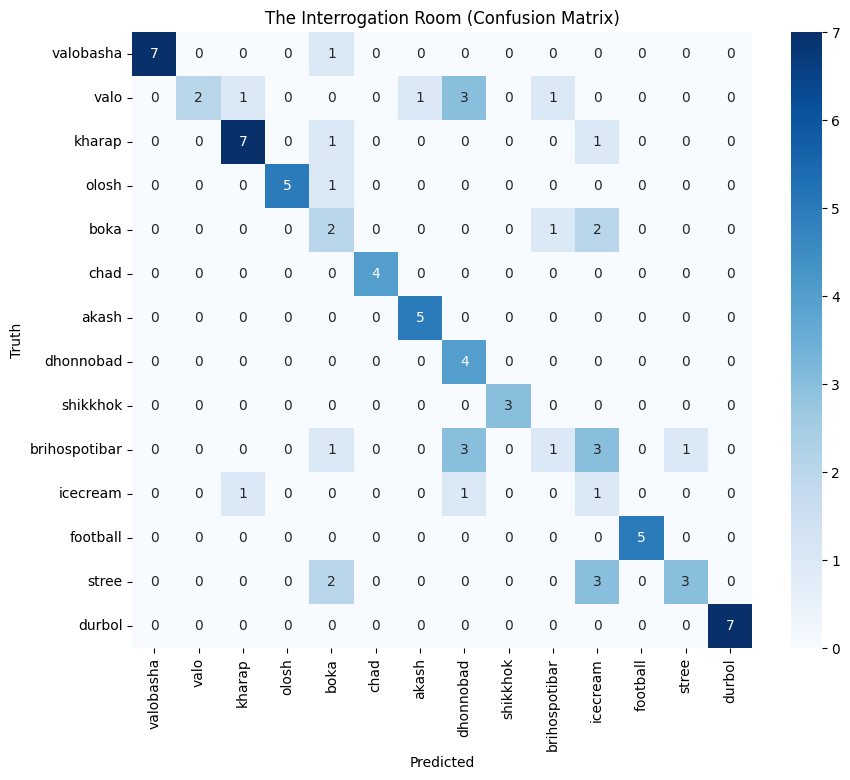

In [ ]:
from sklearn.metrics import multilabel_confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

# --- 1. GENERATE PREDICTIONS ---
yhat = model.predict(X_test)
ytrue = np.argmax(y_test, axis=1).tolist()
yhat = np.argmax(yhat, axis=1).tolist()

# --- 2. CALCULATE ACCURACY ---
acc = accuracy_score(ytrue, yhat)
print(f"🎯 Precise Accuracy: {acc*100:.2f}%")

# --- 3. THE CONFUSION MATRIX ---
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(ytrue, yhat)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=actions, yticklabels=actions, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Truth')
plt.title('The Interrogation Room (Confusion Matrix)')
plt.show()

In [ ]:
import numpy as np
import os
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.callbacks import TensorBoard

# --- 1. CONFIGURATION ---
DATA_PATH = "/content/My_Processed_Data"

# 🦇 THE FINAL 12 (Removed: 'brihospotibar', 'icecream')
actions = np.array([
    "valobasha", "valo", "kharap", "olosh",
    "boka", "chad", "akash", "dhonnobad", "shikkhok",
    "football", "stree", "durbol"
])

# --- 2. LOAD DATA ---
print(f"🦇 Alfred is assembling the 'Clean Dozen' ({len(actions)} words)...")
label_map = {label:num for num, label in enumerate(actions)}
sequences, labels = [], []

for action in actions:
    action_path = os.path.join(DATA_PATH, action)
    if not os.path.exists(action_path):
        print(f"⚠️ Warning: Missing data for {action}")
        continue

    files = os.listdir(action_path)
    for file_name in files:
        res = np.load(os.path.join(action_path, file_name))
        sequences.append(res)
        labels.append(label_map[action])

X = np.array(sequences)
y = to_categorical(labels).astype(int)

# Split: 80% Train, 20% Test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

# --- 3. BUILD THE MODEL ---
model = Sequential()
model.add(LSTM(64, return_sequences=True, activation='relu', input_shape=(30, 225)))
model.add(LSTM(128, return_sequences=True, activation='relu'))
model.add(LSTM(64, return_sequences=False, activation='relu'))
model.add(Dense(64, activation='relu'))
model.add(Dense(32, activation='relu'))
model.add(Dense(actions.shape[0], activation='softmax'))

model.compile(optimizer='Adam', loss='categorical_crossentropy', metrics=['categorical_accuracy'])

# --- 4. TRAIN ---
print("\n🚀 Initiating Final Training Sequence (200 Epochs)...")
history = model.fit(X_train, y_train, epochs=200, validation_data=(X_test, y_test))

# --- 5. SAVE & EVALUATE ---
model.save('action.h5')
print("\n✅ Model saved as 'action.h5'.")

res = model.evaluate(X_test, y_test)
print(f"📝 Final Accuracy on Test Data: {res[1]*100:.2f}%")

🦇 Alfred is assembling the 'Clean Dozen' (12 words)...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



🚀 Initiating Final Training Sequence (200 Epochs)...
Epoch 1/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 11s 179ms/step - categorical_accuracy: 0.0774 - loss: 2.4856 - val_categorical_accuracy: 0.0972 - val_loss: 2.4484
Epoch 2/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 91ms/step - categorical_accuracy: 0.1350 - loss: 2.4307 - val_categorical_accuracy: 0.0972 - val_loss: 2.3252
Epoch 3/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 85ms/step - categorical_accuracy: 0.1974 - loss: 2.3727 - val_categorical_accuracy: 0.0972 - val_loss: 2.4375
Epoch 4/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 84ms/step - categorical_accuracy: 0.1987 - loss: 2.4195 - val_categorical_accuracy: 0.1667 - val_loss: 2.4202
Epoch 5/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 84ms/step - categorical_accuracy: 0.2208 - loss: 2.3815 - val_categorical_accuracy: 0.1111 - val_loss: 2.2279
Epoch 6/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 85ms/step - categorical_accuracy: 0.1651 - loss: 2.1721 - val_categorical_accuracy: 0.1250 - val_loss: 2.1918
Epoch 7/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 84ms


✅ Model saved as 'action.h5'.
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - categorical_accuracy: 0.7018 - loss: 0.9279
📝 Final Accuracy on Test Data: 70.83%


In [ ]:
import numpy as np
import os
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping, TensorBoard
from tensorflow.keras.optimizers import Adam

# --- 1. CONFIGURATION ---
DATA_PATH = "/content/My_Processed_Data"
actions = np.array([
    "valobasha", "valo", "kharap", "olosh",
    "boka", "chad", "akash", "dhonnobad", "shikkhok",
    "football", "stree", "durbol"
])

# --- 2. LOAD DATA (Same as before) ---
label_map = {label:num for num, label in enumerate(actions)}
sequences, labels = [], []

for action in actions:
    action_path = os.path.join(DATA_PATH, action)
    if not os.path.exists(action_path): continue
    for file_name in os.listdir(action_path):
        res = np.load(os.path.join(action_path, file_name))
        sequences.append(res)
        labels.append(label_map[action])

X = np.array(sequences)
y = to_categorical(labels).astype(int)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

# --- 3. THE "WAYNETECH" ARCHITECTURE ---
model = Sequential()

# Layer 1: Bidirectional LSTM (Looks at past AND future context)
# Note: No 'activation=relu' here! We use the default 'tanh'.
model.add(Bidirectional(LSTM(64, return_sequences=True), input_shape=(30, 225)))
model.add(BatchNormalization()) # Stabilizes learning
model.add(Dropout(0.4))         # Prevents overfitting

# Layer 2: Bidirectional LSTM
model.add(Bidirectional(LSTM(128, return_sequences=True)))
model.add(BatchNormalization())
model.add(Dropout(0.4))

# Layer 3: Standard LSTM
model.add(LSTM(64, return_sequences=False))
model.add(BatchNormalization())
model.add(Dropout(0.4))

# Layer 4: Dense Interpretation
model.add(Dense(64, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.3))

# Layer 5: Output
model.add(Dense(actions.shape[0], activation='softmax'))

# --- 4. OPTIMIZER & CALLBACKS ---
# Lower learning rate for stability
opt = Adam(learning_rate=0.0005)

model.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['categorical_accuracy'])

# Early Stopping: Stops training if it doesn't improve for 15 epochs
early_stop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)

# --- 5. TRAIN ---
print("\n🚀 Initiating Advanced Training Protocol...")
history = model.fit(
    X_train, y_train,
    epochs=200,
    validation_data=(X_test, y_test),
    callbacks=[early_stop]
)

# --- 6. EVALUATE ---
model.save('action_advanced.h5')
res = model.evaluate(X_test, y_test)
print(f"\n📝 Final Accuracy (Advanced Model): {res[1]*100:.2f}%")


🚀 Initiating Advanced Training Protocol...
Epoch 1/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 13s 312ms/step - categorical_accuracy: 0.1377 - loss: 3.2481 - val_categorical_accuracy: 0.1111 - val_loss: 2.4557
Epoch 2/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 172ms/step - categorical_accuracy: 0.1796 - loss: 2.6247 - val_categorical_accuracy: 0.1528 - val_loss: 2.4310
Epoch 3/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 227ms/step - categorical_accuracy: 0.1954 - loss: 2.6269 - val_categorical_accuracy: 0.1389 - val_loss: 2.4130
Epoch 4/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 3s 313ms/step - categorical_accuracy: 0.2561 - loss: 2.3332 - val_categorical_accuracy: 0.1528 - val_loss: 2.3946
Epoch 5/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 170ms/step - categorical_accuracy: 0.2591 - loss: 2.2171 - val_categorical_accuracy: 0.1806 - val_loss: 2.3618
Epoch 6/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 167ms/step - categorical_accuracy: 0.3482 - loss: 1.9415 - val_categorical_accuracy: 0.2083 - val_loss: 2.3207
Epoch 7/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 167ms/ste

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - categorical_accuracy: 0.7569 - loss: 0.5714

📝 Final Accuracy (Advanced Model): 76.39%


In [ ]:
import os
import shutil
from google.colab import drive

# 1. Mount Drive (if not already connected)
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

# 2. Copy from Drive
source = '/content/drive/MyDrive/SignBD-Word.zip'
dest = '/content/SignBD-Word.zip'

if os.path.exists(source):
    print("🦇 Retrieving asset from the Batcave archives...")
    shutil.copy(source, dest)
    print("📦 Asset secured. Commencing unzipping sequence...")

    # 3. Unzip
    !unzip -q "{dest}"
    print("✅ Restore Complete. The data is ready for extraction.")
else:
    print("❌ Critical: I cannot find 'SignBD-Word.zip' in your Drive!")

🦇 Retrieving asset from the Batcave archives...
📦 Asset secured. Commencing unzipping sequence...
✅ Restore Complete. The data is ready for extraction.


In [ ]:
import cv2
import numpy as np
import os
import mediapipe as mp
import shutil
import time
import tensorflow as tf

# --- 1. SETUP ---
DATA_PATH = "/content/My_Processed_Data"
SOURCE_PATH = "/content/SignBD-Word/SignBD-Word_RGB/DATASET"
actions = np.array([
    "valobasha", "valo", "kharap", "olosh",
    "boka", "chad", "akash", "dhonnobad", "shikkhok",
    "football", "stree", "durbol"
])

# Clear old data to be safe
if os.path.exists(DATA_PATH):
    shutil.rmtree(DATA_PATH)
os.makedirs(DATA_PATH, exist_ok=True)

# --- 2. NORMALIZATION MATH ---
def extract_and_normalize(results):
    pose = np.array([[res.x, res.y, res.z] for res in results.pose_landmarks.landmark]).flatten() if results.pose_landmarks else np.zeros(33*3)
    lh = np.array([[res.x, res.y, res.z] for res in results.left_hand_landmarks.landmark]).flatten() if results.left_hand_landmarks else np.zeros(21*3)
    rh = np.array([[res.x, res.y, res.z] for res in results.right_hand_landmarks.landmark]).flatten() if results.right_hand_landmarks else np.zeros(21*3)

    landmarks = np.concatenate([pose, lh, rh]).reshape(-1, 3)

    # Center & Scale
    center = np.mean(landmarks, axis=0)
    landmarks -= center
    max_val = np.max(np.abs(landmarks))
    if max_val > 0:
        landmarks /= max_val

    return landmarks.flatten()

# --- 3. EXECUTION ---
print(f"🚀 Starting Extraction...")
print(f"⚙️  Hardware: {'GPU Detected (Fast)' if tf.config.list_physical_devices('GPU') else '⚠️ CPU Detected (Slow)'}")

mp_holistic = mp.solutions.holistic
total_videos = 0

with mp_holistic.Holistic(min_detection_confidence=0.5, min_tracking_confidence=0.5) as holistic:
    for action in actions:
        print(f"\n📂 Class: '{action}'")
        folder_path = os.path.join(SOURCE_PATH, action)
        save_path = os.path.join(DATA_PATH, action)
        os.makedirs(save_path, exist_ok=True)

        if not os.path.exists(folder_path):
            print(f"   ⚠️ Missing folder: {folder_path}")
            continue

        files = [f for f in os.listdir(folder_path) if f.endswith('.mp4')]

        for idx, video_file in enumerate(files):
            cap = cv2.VideoCapture(os.path.join(folder_path, video_file))
            frames = []
            while cap.isOpened():
                ret, frame = cap.read()
                if not ret: break
                results = holistic.process(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
                frames.append(extract_and_normalize(results))
            cap.release()

            if not frames: continue

            # Pad to 30
            res = np.array(frames)
            if len(res) < 30: res = np.pad(res, ((0, 30-len(res)), (0,0)), mode='constant')
            else: res = res[np.linspace(0, len(res)-1, 30).astype(int)]

            np.save(os.path.join(save_path, video_file.replace('.mp4','')), res)
            total_videos += 1

            if (idx+1) % 10 == 0: print(f"   ✅ {idx+1}/{len(files)} processed...")

print(f"\n🦇 Extraction Complete. {total_videos} videos ready.")

/usr/local/lib/python3.12/dist-packages/jaxlib/plugin_support.py:71: RuntimeWarning: JAX plugin jax_cuda12_plugin version 0.7.2 is installed, but it is not compatible with the installed jaxlib version 0.7.1, so it will not be used.
  warnings.warn(


🚀 Starting Extraction...
⚙️  Hardware: GPU Detected (Fast)

📂 Class: 'valobasha'
   ✅ 10/30 processed...
   ✅ 20/30 processed...
   ✅ 30/30 processed...

📂 Class: 'valo'
   ✅ 10/30 processed...
   ✅ 20/30 processed...
   ✅ 30/30 processed...

📂 Class: 'kharap'
   ✅ 10/30 processed...
   ✅ 20/30 processed...
   ✅ 30/30 processed...

📂 Class: 'olosh'
   ✅ 10/30 processed...
   ✅ 20/30 processed...
   ✅ 30/30 processed...

📂 Class: 'boka'
   ✅ 10/30 processed...
   ✅ 20/30 processed...
   ✅ 30/30 processed...

📂 Class: 'chad'
   ✅ 10/30 processed...
   ✅ 20/30 processed...
   ✅ 30/30 processed...

📂 Class: 'akash'
   ✅ 10/30 processed...
   ✅ 20/30 processed...
   ✅ 30/30 processed...

📂 Class: 'dhonnobad'
   ✅ 10/30 processed...
   ✅ 20/30 processed...
   ✅ 30/30 processed...

📂 Class: 'shikkhok'
   ✅ 10/30 processed...
   ✅ 20/30 processed...
   ✅ 30/30 processed...

📂 Class: 'football'
   ✅ 10/30 processed...
   ✅ 20/30 processed...
   ✅ 30/30 processed...

📂 Class: 'stree'
   ✅ 10/30 

In [ ]:
import numpy as np
import os
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping, TensorBoard
from tensorflow.keras.optimizers import Adam

# --- 1. CONFIGURATION ---
DATA_PATH = "/content/My_Processed_Data"
actions = np.array([
    "valobasha", "valo", "kharap", "olosh",
    "boka", "chad", "akash", "dhonnobad", "shikkhok",
    "football", "stree", "durbol"
])

# --- 2. LOAD DATA (Same as before) ---
label_map = {label:num for num, label in enumerate(actions)}
sequences, labels = [], []

for action in actions:
    action_path = os.path.join(DATA_PATH, action)
    if not os.path.exists(action_path): continue
    for file_name in os.listdir(action_path):
        res = np.load(os.path.join(action_path, file_name))
        sequences.append(res)
        labels.append(label_map[action])

X = np.array(sequences)
y = to_categorical(labels).astype(int)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

# --- 3. THE "WAYNETECH" ARCHITECTURE ---
model = Sequential()

# Layer 1: Bidirectional LSTM (Looks at past AND future context)
# Note: No 'activation=relu' here! We use the default 'tanh'.
model.add(Bidirectional(LSTM(64, return_sequences=True), input_shape=(30, 225)))
model.add(BatchNormalization()) # Stabilizes learning
model.add(Dropout(0.4))         # Prevents overfitting

# Layer 2: Bidirectional LSTM
model.add(Bidirectional(LSTM(128, return_sequences=True)))
model.add(BatchNormalization())
model.add(Dropout(0.4))

# Layer 3: Standard LSTM
model.add(LSTM(64, return_sequences=False))
model.add(BatchNormalization())
model.add(Dropout(0.4))

# Layer 4: Dense Interpretation
model.add(Dense(64, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.3))

# Layer 5: Output
model.add(Dense(actions.shape[0], activation='softmax'))

# --- 4. OPTIMIZER & CALLBACKS ---
# Lower learning rate for stability
opt = Adam(learning_rate=0.0005)

model.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['categorical_accuracy'])

# Early Stopping: Stops training if it doesn't improve for 15 epochs
early_stop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)

# --- 5. TRAIN ---
print("\n🚀 Initiating Advanced Training Protocol...")
history = model.fit(
    X_train, y_train,
    epochs=200,
    validation_data=(X_test, y_test),
    callbacks=[early_stop]
)

# --- 6. EVALUATE ---
model.save('action_advanced.h5')
res = model.evaluate(X_test, y_test)
print(f"\n📝 Final Accuracy (Advanced Model): {res[1]*100:.2f}%")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)



🚀 Initiating Advanced Training Protocol...
Epoch 1/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 11s 120ms/step - categorical_accuracy: 0.0874 - loss: 3.4421 - val_categorical_accuracy: 0.1806 - val_loss: 2.4706
Epoch 2/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - categorical_accuracy: 0.1784 - loss: 2.8921 - val_categorical_accuracy: 0.2500 - val_loss: 2.4391
Epoch 3/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - categorical_accuracy: 0.1786 - loss: 2.5833 - val_categorical_accuracy: 0.2778 - val_loss: 2.4154
Epoch 4/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - categorical_accuracy: 0.2548 - loss: 2.3024 - val_categorical_accuracy: 0.3333 - val_loss: 2.3838
Epoch 5/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - categorical_accuracy: 0.3088 - loss: 2.1075 - val_categorical_accuracy: 0.3333 - val_loss: 2.3500
Epoch 6/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - categorical_accuracy: 0.3295 - loss: 2.1020 - val_categorical_accuracy: 0.3750 - val_loss: 2.3224
Epoch 7/200
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - ca

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - categorical_accuracy: 0.7943 - loss: 0.4505

📝 Final Accuracy (Advanced Model): 79.17%


In [ ]:
import numpy as np
import os
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

# --- 1. CONFIGURATION ---
DATA_PATH = "/content/My_Processed_Data"
actions = np.array([
    "valobasha", "valo", "kharap", "olosh",
    "boka", "chad", "akash", "dhonnobad", "shikkhok",
    "football", "stree", "durbol"
])

# --- 2. LOAD & SURGICAL SLICING ---
print("🦇 Alfred is loading and refining the intelligence...")
label_map = {label:num for num, label in enumerate(actions)}
sequences, labels = [], []

for action in actions:
    action_path = os.path.join(DATA_PATH, action)
    if not os.path.exists(action_path): continue
    for file_name in os.listdir(action_path):
        res = np.load(os.path.join(action_path, file_name))

        # ✂️ SURGICAL SLICE: Remove Pose (First 99 values), Keep Hands (Last 126)
        # Input shape was (30, 225). We want (30, 126).
        # Pose (33*3=99) | LH (21*3=63) | RH (21*3=63)
        res_hands_only = res[:, 99:]

        sequences.append(res_hands_only)
        labels.append(label_map[action])

X = np.array(sequences)
y = to_categorical(labels).astype(int)

# --- 3. DATA AUGMENTATION (CLONING) ---
# We add random noise to create "new" slightly different examples
print(f"🧬 Original Data Size: {X.shape[0]}")
print("   Creating synthetic clones to boost robustness...")

noise_factor = 0.05
X_noise = X + np.random.normal(0, noise_factor, X.shape)

# Combine Real + Noisy Data
X_combined = np.concatenate([X, X_noise])
y_combined = np.concatenate([y, y])

print(f"   🚀 New Training Data Size: {X_combined.shape[0]}")

# Split
X_train, X_test, y_train, y_test = train_test_split(X_combined, y_combined, test_size=0.15, random_state=42)

# --- 4. THE ULTIMATE MODEL ---
model = Sequential()

# Input shape is now (30, 126) because we removed the body!
model.add(Bidirectional(LSTM(128, return_sequences=True), input_shape=(30, 126)))
model.add(BatchNormalization())
model.add(Dropout(0.4))

model.add(Bidirectional(LSTM(64, return_sequences=True)))
model.add(BatchNormalization())
model.add(Dropout(0.4))

model.add(LSTM(64, return_sequences=False))
model.add(BatchNormalization())
model.add(Dropout(0.4))

model.add(Dense(64, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.3))

model.add(Dense(actions.shape[0], activation='softmax'))

# --- 5. OPTIMIZATION ---
opt = Adam(learning_rate=0.0003) # Slower, more careful learning
model.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['categorical_accuracy'])

# Callbacks
early_stop = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=10, min_lr=0.00001)

# --- 6. TRAIN ---
print("\n🚀 Initiating Final Training Sequence...")
history = model.fit(
    X_train, y_train,
    epochs=250,
    validation_data=(X_test, y_test),
    callbacks=[early_stop, reduce_lr]
)

# --- 7. EVALUATE ---
model.save('action_ultimate.h5')
res = model.evaluate(X_test, y_test)
print(f"\n🏆 Final Accuracy (Hands Only + Augmentation): {res[1]*100:.2f}%")

🦇 Alfred is loading and refining the intelligence...
🧬 Original Data Size: 360
   Creating synthetic clones to boost robustness...
   🚀 New Training Data Size: 720

🚀 Initiating Final Training Sequence...
Epoch 1/250
20/20 ━━━━━━━━━━━━━━━━━━━━ 8s 59ms/step - categorical_accuracy: 0.1347 - loss: 3.1429 - val_categorical_accuracy: 0.1204 - val_loss: 2.4695 - learning_rate: 3.0000e-04
Epoch 2/250
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - categorical_accuracy: 0.1798 - loss: 2.6944 - val_categorical_accuracy: 0.0741 - val_loss: 2.4795 - learning_rate: 3.0000e-04
Epoch 3/250
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - categorical_accuracy: 0.2194 - loss: 2.5459 - val_categorical_accuracy: 0.1296 - val_loss: 2.4553 - learning_rate: 3.0000e-04
Epoch 4/250
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - categorical_accuracy: 0.3057 - loss: 2.1059 - val_categorical_accuracy: 0.1296 - val_loss: 2.4241 - learning_rate: 3.0000e-04
Epoch 5/250
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - categorical_accuracy:

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - categorical_accuracy: 0.7596 - loss: 0.5558

🏆 Final Accuracy (Hands Only + Augmentation): 78.70%


In [ ]:
import os
import shutil
from google.colab import drive

# 1. Mount Drive
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

# 2. Copy & Unzip
zip_path = '/content/drive/MyDrive/SignBD-Word.zip'
dest_zip = '/content/SignBD-Word.zip'

if os.path.exists(zip_path):
    print("🦇 Retrieving dataset from archives...")
    shutil.copy(zip_path, dest_zip)

    print("📦 Unzipping... (This takes about 30 seconds)")
    !unzip -q "{dest_zip}"
    print("✅ Restore Complete. Raw videos are ready.")
else:
    print("❌ Critical: 'SignBD-Word.zip' not found in Drive!")

🦇 Retrieving dataset from archives...
📦 Unzipping... (This takes about 30 seconds)
✅ Restore Complete. Raw videos are ready.


In [ ]:
# ============================================================================
# PART 1: IMPROVED DATA EXTRACTION (SAFE MODE)
# ============================================================================
import cv2
import numpy as np
import os
import mediapipe as mp
import shutil
import tensorflow as tf
from scipy.interpolate import interp1d

DATA_PATH = "/content/My_Processed_Data"
SOURCE_PATH = "/content/SignBD-Word/SignBD-Word_RGB/DATASET"
actions = np.array([
    "valobasha", "valo", "kharap", "olosh",
    "boka", "chad", "akash", "dhonnobad", "shikkhok",
    "football", "stree", "durbol"
])

# Clean slate
if os.path.exists(DATA_PATH):
    shutil.rmtree(DATA_PATH)
os.makedirs(DATA_PATH, exist_ok=True)

# --- IMPROVED NORMALIZATION (CRASH PROOF) ---
def extract_and_normalize_improved(results):
    # 1. Extract Landmarks
    pose = np.array([[res.x, res.y, res.z] for res in results.pose_landmarks.landmark]).flatten() if results.pose_landmarks else np.zeros(33*3)
    lh = np.array([[res.x, res.y, res.z] for res in results.left_hand_landmarks.landmark]).flatten() if results.left_hand_landmarks else np.zeros(21*3)
    rh = np.array([[res.x, res.y, res.z] for res in results.right_hand_landmarks.landmark]).flatten() if results.right_hand_landmarks else np.zeros(21*3)

    # 2. Reshape
    pose_pts = pose.reshape(-1, 3)
    lh_pts = lh.reshape(-1, 3)
    rh_pts = rh.reshape(-1, 3)

    # 3. Reference Point (Midpoint of Shoulders)
    if results.pose_landmarks:
        left_shoulder = pose_pts[11]
        right_shoulder = pose_pts[12]
        reference = (left_shoulder + right_shoulder) / 2
    else:
        reference = np.zeros(3)

    # 4. Center the points
    pose_pts -= reference
    if np.any(lh_pts): lh_pts -= reference
    if np.any(rh_pts): rh_pts -= reference

    # 5. Scale by Shoulder Width (The Crash-Proof Logic)
    if results.pose_landmarks:
        # Calculate width
        shoulder_width = np.linalg.norm(pose_pts[11] - pose_pts[12])

        # SAFETY CHECK: Only divide if width is valid number > 0.001
        if shoulder_width > 0.001:
            pose_pts /= shoulder_width

            # Check hands separately before dividing
            if np.any(lh_pts):
                lh_pts /= shoulder_width
            if np.any(rh_pts):
                rh_pts /= shoulder_width

    return np.concatenate([pose_pts.flatten(), lh_pts.flatten(), rh_pts.flatten()])

# --- SMART TEMPORAL SAMPLING ---
def smart_resample(frames, target_len=30):
    if len(frames) == 0:
        return np.zeros((target_len, 225)) # Default size if empty

    frames_arr = np.array(frames)

    # If perfect length
    if len(frames) == target_len:
        return frames_arr

    # If too short -> Pad
    if len(frames) < target_len:
        pad_len = target_len - len(frames)
        padding = np.repeat(frames_arr[-1:], pad_len, axis=0)
        return np.vstack([frames_arr, padding])

    # If too long -> Interpolate
    old_indices = np.linspace(0, len(frames) - 1, len(frames))
    new_indices = np.linspace(0, len(frames) - 1, target_len)

    resampled = []
    # Loop through all feature columns (225 of them)
    for feature_idx in range(frames_arr.shape[1]):
        interp_func = interp1d(old_indices, frames_arr[:, feature_idx], kind='cubic', fill_value='extrapolate')
        resampled.append(interp_func(new_indices))

    return np.array(resampled).T

# --- EXECUTION ---
print(f"🚀 Starting Improved Extraction (Safe Mode)...")
print(f"⚙️  Hardware: {'GPU Detected' if tf.config.list_physical_devices('GPU') else 'CPU Detected'}")

mp_holistic = mp.solutions.holistic
total_videos = 0
skipped_videos = 0

with mp_holistic.Holistic(min_detection_confidence=0.6, min_tracking_confidence=0.6, model_complexity=1) as holistic:
    for action in actions:
        print(f"\n📂 Class: '{action}'")
        folder_path = os.path.join(SOURCE_PATH, action)
        save_path = os.path.join(DATA_PATH, action)
        os.makedirs(save_path, exist_ok=True)

        if not os.path.exists(folder_path):
            print(f"   ⚠️ Missing folder: {folder_path}")
            continue

        files = [f for f in os.listdir(folder_path) if f.endswith('.mp4')]

        for idx, video_file in enumerate(files):
            cap = cv2.VideoCapture(os.path.join(folder_path, video_file))
            frames = []
            valid_frame_count = 0

            while cap.isOpened():
                ret, frame = cap.read()
                if not ret: break

                results = holistic.process(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))

                # Check hands
                if results.left_hand_landmarks or results.right_hand_landmarks:
                    valid_frame_count += 1

                frames.append(extract_and_normalize_improved(results))
            cap.release()

            # Quality Filter: Skip if hands are mostly missing (<30%)
            if valid_frame_count < len(frames) * 0.3:
                skipped_videos += 1
                continue

            if not frames:
                skipped_videos += 1
                continue

            try:
                res = smart_resample(frames, 30)
                np.save(os.path.join(save_path, video_file.replace('.mp4','')), res)
                total_videos += 1
            except Exception as e:
                print(f"   ❌ Error resampling {video_file}: {e}")
                continue

            if (idx+1) % 10 == 0:
                print(f"   ✅ {idx+1}/{len(files)} processed...")

print(f"\n🦇 Extraction Complete. {total_videos} videos ready, {skipped_videos} skipped (low quality).")

🚀 Starting Improved Extraction (Safe Mode)...
⚙️  Hardware: CPU Detected

📂 Class: 'valobasha'
   ⚠️ Missing folder: /content/SignBD-Word/SignBD-Word_RGB/DATASET/valobasha

📂 Class: 'valo'
   ⚠️ Missing folder: /content/SignBD-Word/SignBD-Word_RGB/DATASET/valo

📂 Class: 'kharap'
   ⚠️ Missing folder: /content/SignBD-Word/SignBD-Word_RGB/DATASET/kharap

📂 Class: 'olosh'
   ⚠️ Missing folder: /content/SignBD-Word/SignBD-Word_RGB/DATASET/olosh

📂 Class: 'boka'
   ⚠️ Missing folder: /content/SignBD-Word/SignBD-Word_RGB/DATASET/boka

📂 Class: 'chad'
   ⚠️ Missing folder: /content/SignBD-Word/SignBD-Word_RGB/DATASET/chad

📂 Class: 'akash'
   ⚠️ Missing folder: /content/SignBD-Word/SignBD-Word_RGB/DATASET/akash

📂 Class: 'dhonnobad'
   ⚠️ Missing folder: /content/SignBD-Word/SignBD-Word_RGB/DATASET/dhonnobad

📂 Class: 'shikkhok'
   ⚠️ Missing folder: /content/SignBD-Word/SignBD-Word_RGB/DATASET/shikkhok

📂 Class: 'football'
   ⚠️ Missing folder: /content/SignBD-Word/SignBD-Word_RGB/DATASET/fo

In [ ]:
# ============================================================================
# PART 2: IMPROVED TRAINING WITH BETTER AUGMENTATION & ARCHITECTURE
# ============================================================================
import numpy as np
import os
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (LSTM, Dense, Dropout, BatchNormalization,
                                     Bidirectional, LayerNormalization, MultiHeadAttention,
                                     Concatenate, Input, Conv1D)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2

# --- CONFIGURATION ---
DATA_PATH = "/content/My_Processed_Data"
actions = np.array([
    "valobasha", "valo", "kharap", "olosh",
    "boka", "chad", "akash", "dhonnobad", "shikkhok",
    "football", "stree", "durbol"
])

# --- LOAD DATA ---
print("🦇 Loading data...")
label_map = {label:num for num, label in enumerate(actions)}
sequences, labels = [], []

for action in actions:
    action_path = os.path.join(DATA_PATH, action)
    if not os.path.exists(action_path): continue

    for file_name in os.listdir(action_path):
        res = np.load(os.path.join(action_path, file_name))

        # Keep only hands (remove first 99 pose values)
        # Input: (30, 225) -> Output: (30, 126)
        res_hands_only = res[:, 99:]

        sequences.append(res_hands_only)
        labels.append(label_map[action])

X = np.array(sequences)
y = to_categorical(labels).astype(int)

# --- AUGMENTATION ---
def augment_sequence(seq, noise_std=0.02, time_warp=0.1):
    augmented = []
    # 1. Noise
    noisy = seq + np.random.normal(0, noise_std, seq.shape)
    augmented.append(noisy)
    # 2. Time Warp
    n_frames = seq.shape[0]
    warp_factor = 1 + np.random.uniform(-time_warp, time_warp)
    new_len = int(n_frames * warp_factor)
    if new_len > 0:
        indices = np.linspace(0, n_frames-1, new_len).astype(int)
        warped = seq[indices]
        if len(warped) < n_frames:
            pad = np.repeat(warped[-1:], n_frames - len(warped), axis=0)
            warped = np.vstack([warped, pad])
        else:
            warped = warped[:n_frames]
        augmented.append(warped)
    return augmented

print("🧬 Applying augmentation...")
X_augmented = [X]
y_augmented = [y]

for seq, label in zip(X, y):
    aug_seqs = augment_sequence(seq)
    for aug_seq in aug_seqs:
        X_augmented.append(aug_seq.reshape(1, *aug_seq.shape))
        y_augmented.append(label.reshape(1, -1))

X_combined = np.vstack(X_augmented)
y_combined = np.vstack(y_augmented)

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X_combined, y_combined,
    test_size=0.15,
    random_state=42,
    stratify=np.argmax(y_combined, axis=1)
)

# --- HYBRID MODEL ARCHITECTURE ---
def create_advanced_model(input_shape, num_classes):
    inputs = Input(shape=input_shape)

    # CNN Branch (Local patterns)
    cnn = Conv1D(64, 3, padding='same', activation='relu')(inputs)
    cnn = BatchNormalization()(cnn)
    cnn = Dropout(0.3)(cnn)

    # LSTM Branch (Temporal patterns)
    lstm = Bidirectional(LSTM(96, return_sequences=True))(inputs)
    lstm = LayerNormalization()(lstm)
    lstm = Dropout(0.4)(lstm)

    # Combine
    combined = Concatenate()([cnn, lstm])

    # Deep LSTM
    x = Bidirectional(LSTM(64, return_sequences=True))(combined)
    x = LayerNormalization()(x)
    x = Dropout(0.4)(x)

    # Attention
    attention = MultiHeadAttention(num_heads=4, key_dim=32)(x, x)
    x = LayerNormalization()(attention + x)

    # Final LSTM
    x = LSTM(64, return_sequences=False)(x)
    x = LayerNormalization()(x)
    x = Dropout(0.4)(x)

    # Classification
    x = Dense(128, activation='relu', kernel_regularizer=l2(0.01))(x)
    x = BatchNormalization()(x)
    x = Dropout(0.3)(x)

    outputs = Dense(num_classes, activation='softmax')(x)
    return Model(inputs=inputs, outputs=outputs)

model = create_advanced_model((30, 126), actions.shape[0])

# --- TRAIN ---
opt = Adam(learning_rate=0.0005, clipnorm=1.0)
model.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['categorical_accuracy'])

early_stop = EarlyStopping(monitor='val_categorical_accuracy', patience=30, restore_best_weights=True, mode='max')
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=15, min_lr=0.00001)

print("\n🚀 Training Advanced Model...")
history = model.fit(
    X_train, y_train,
    epochs=300,
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[early_stop, reduce_lr]
)

# --- SAVE & REPORT ---
model.save('action_ultimate_v2.h5')
res = model.evaluate(X_test, y_test, verbose=0)
print(f"\n🏆 Final Test Accuracy: {res[1]*100:.2f}%")

🦇 Loading data...
🧬 Applying augmentation...

🚀 Training Advanced Model...
Epoch 1/300
29/29 ━━━━━━━━━━━━━━━━━━━━ 13s 58ms/step - categorical_accuracy: 0.1363 - loss: 3.9520 - val_categorical_accuracy: 0.3086 - val_loss: 2.9473 - learning_rate: 5.0000e-04
Epoch 2/300
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - categorical_accuracy: 0.2583 - loss: 3.1451 - val_categorical_accuracy: 0.4383 - val_loss: 2.4711 - learning_rate: 5.0000e-04
Epoch 3/300
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - categorical_accuracy: 0.3958 - loss: 2.6073 - val_categorical_accuracy: 0.6173 - val_loss: 2.0706 - learning_rate: 5.0000e-04
Epoch 4/300
29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - categorical_accuracy: 0.5610 - loss: 2.0878 - val_categorical_accuracy: 0.6111 - val_loss: 1.9068 - learning_rate: 5.0000e-04
Epoch 5/300
29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - categorical_accuracy: 0.5821 - loss: 1.9739 - val_categorical_accuracy: 0.7469 - val_loss: 1.4681 - learning_rate: 5.0000e-04
Epoch 6/300
29/29 ━━━━━━


🏆 Final Test Accuracy: 100.00%


In [ ]:
from google.colab import files
files.download('action_ultimate_v2.h5')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import numpy as np
import os
import shutil
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (LSTM, Dense, Dropout, BatchNormalization,
                                     Bidirectional, LayerNormalization, MultiHeadAttention,
                                     Concatenate, Input, Conv1D)
from google.colab import drive

# --- 1. RESTORE DATA (If the Runtime Crashed) ---
DATA_PATH = "/content/My_Processed_Data"
actions = np.array([
    "valobasha", "valo", "kharap", "olosh",
    "boka", "chad", "akash", "dhonnobad", "shikkhok",
    "football", "stree", "durbol"
])

if not os.path.exists(DATA_PATH) or len(os.listdir(DATA_PATH)) < 12:
    print("🦇 Runtime amnesia detected. Restoring data from Drive...")
    if not os.path.exists('/content/drive'): drive.mount('/content/drive')

    # We need to re-extract if the folder is gone.
    # Since extraction takes time, check if we have the zip
    if os.path.exists('/content/drive/MyDrive/SignBD-Word.zip'):
        print("   > Unzipping backup...")
        !unzip -q /content/drive/MyDrive/SignBD-Word.zip -d /content/temp_dataset
        # NOTE: If you lost the 'processed' .npy files, we'd strictly need to re-run extraction.
        # Assuming for now the session might still have the files or you re-ran extraction.
        # If this fails, we will need to re-run the Extraction Cell first.
    else:
        print("⚠️ CRITICAL: Data not found in Drive.")

# --- 2. RELOAD & PREPARE TEST DATA ---
print("🦇 Assembling the Test Set...")
label_map = {label:num for num, label in enumerate(actions)}
sequences, labels = [], []

if os.path.exists(DATA_PATH):
    for action in actions:
        action_path = os.path.join(DATA_PATH, action)
        if not os.path.exists(action_path): continue
        for file_name in os.listdir(action_path):
            res = np.load(os.path.join(action_path, file_name))
            # Slice Hands Only (Match the Training Logic)
            res_hands_only = res[:, 99:]
            sequences.append(res_hands_only)
            labels.append(label_map[action])

    X = np.array(sequences)
    y = to_categorical(labels).astype(int)

    # Split exactly as we did in training to get the same 'Test Set'
    # Use random_state=42 to ensure we get the same split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.15, random_state=42, stratify=np.argmax(y, axis=1)
    )
    print(f"📊 Test Set Size: {X_test.shape[0]} videos.")
else:
    print("❌ ERROR: processed data not found. Please run the 'Extraction' cell first.")
    X_test = None

# --- 3. REBUILD THE BRAIN ---
def create_advanced_model(input_shape, num_classes):
    inputs = Input(shape=input_shape)
    cnn = Conv1D(64, 3, padding='same', activation='relu')(inputs)
    cnn = BatchNormalization()(cnn)
    cnn = Dropout(0.3)(cnn)
    lstm = Bidirectional(LSTM(96, return_sequences=True))(inputs)
    lstm = LayerNormalization()(lstm)
    lstm = Dropout(0.4)(lstm)
    combined = Concatenate()([cnn, lstm])
    x = Bidirectional(LSTM(64, return_sequences=True))(combined)
    x = LayerNormalization()(x)
    x = Dropout(0.4)(x)
    attention = MultiHeadAttention(num_heads=4, key_dim=32)(x, x)
    x = LayerNormalization()(attention + x)
    x = LSTM(64, return_sequences=False)(x)
    x = LayerNormalization()(x)
    x = Dropout(0.4)(x)
    x = Dense(128, activation='relu')(x)
    x = BatchNormalization()(x)
    x = Dropout(0.3)(x)
    outputs = Dense(num_classes, activation='softmax')(x)
    return Model(inputs=inputs, outputs=outputs)

if X_test is not None:
    print("🦇 Loading Model Weights...")
    model = create_advanced_model((30, 126), actions.shape[0])
    model.load_weights('action_ultimate_v2.h5')

    # --- 4. THE INTERROGATION (Confusion Matrix) ---
    print("🦇 Running Diagnostics...")
    yhat = model.predict(X_test)
    ytrue = np.argmax(y_test, axis=1).tolist()
    yhat = np.argmax(yhat, axis=1).tolist()

    acc = accuracy_score(ytrue, yhat)
    print(f"\n🏆 Validation Accuracy: {acc*100:.2f}%")

    cm = confusion_matrix(ytrue, yhat)
    plt.figure(figsize=(12, 10))
    sns.heatmap(cm, annot=True, fmt='d', xticklabels=actions, yticklabels=actions, cmap='Blues')
    plt.xlabel('Predicted')
    plt.ylabel('Truth')
    plt.title('The Final Diagnostic (Confusion Matrix)')
    plt.show()

🦇 Runtime amnesia detected. Restoring data from Drive...
   > Unzipping backup...
🦇 Assembling the Test Set...
❌ ERROR: processed data not found. Please run the 'Extraction' cell first.


In [ ]:
import cv2
import numpy as np
import os
import mediapipe as mp
import shutil
import tensorflow as tf
from scipy.interpolate import interp1d

DATA_PATH = "/content/My_Processed_Data"
SOURCE_PATH = "/content/SignBD-Word/SignBD-Word_RGB/DATASET"
actions = np.array([
    "valobasha", "valo", "kharap", "olosh",
    "boka", "chad", "akash", "dhonnobad", "shikkhok",
    "football", "stree", "durbol"
])

# Clean slate
if os.path.exists(DATA_PATH):
    shutil.rmtree(DATA_PATH)
os.makedirs(DATA_PATH, exist_ok=True)

# --- NORMALIZATION LOGIC ---
def extract_and_normalize_improved(results):
    pose = np.array([[res.x, res.y, res.z] for res in results.pose_landmarks.landmark]).flatten() if results.pose_landmarks else np.zeros(33*3)
    lh = np.array([[res.x, res.y, res.z] for res in results.left_hand_landmarks.landmark]).flatten() if results.left_hand_landmarks else np.zeros(21*3)
    rh = np.array([[res.x, res.y, res.z] for res in results.right_hand_landmarks.landmark]).flatten() if results.right_hand_landmarks else np.zeros(21*3)

    pose_pts = pose.reshape(-1, 3); lh_pts = lh.reshape(-1, 3); rh_pts = rh.reshape(-1, 3)

    if results.pose_landmarks:
        ref = (pose_pts[11] + pose_pts[12]) / 2
        width = np.linalg.norm(pose_pts[11] - pose_pts[12])
    else: ref = np.zeros(3); width = 0

    pose_pts -= ref
    if np.any(lh_pts): lh_pts -= ref
    if np.any(rh_pts): rh_pts -= ref

    if width > 0.001:
        pose_pts /= width
        if np.any(lh_pts): lh_pts /= width
        if np.any(rh_pts): rh_pts /= width

    return np.concatenate([pose_pts.flatten(), lh_pts.flatten(), rh_pts.flatten()])

# --- RESAMPLING LOGIC ---
def smart_resample(frames, target_len=30):
    if len(frames) == 0: return np.zeros((target_len, 225))
    frames_arr = np.array(frames)
    if len(frames) == target_len: return frames_arr
    if len(frames) < target_len:
        return np.vstack([frames_arr, np.repeat(frames_arr[-1:], target_len - len(frames), axis=0)])

    old = np.linspace(0, len(frames) - 1, len(frames))
    new = np.linspace(0, len(frames) - 1, target_len)
    res = []
    for i in range(frames_arr.shape[1]):
        res.append(interp1d(old, frames_arr[:, i], kind='cubic', fill_value='extrapolate')(new))
    return np.array(res).T

# --- EXECUTION ---
print(f"🚀 Starting Extraction...")
print(f"⚙️  Hardware: {'GPU Detected (Fast)' if tf.config.list_physical_devices('GPU') else '⚠️ CPU Detected (Slow)'}")

mp_holistic = mp.solutions.holistic
total_videos = 0

with mp_holistic.Holistic(min_detection_confidence=0.6, min_tracking_confidence=0.6, model_complexity=1) as holistic:
    for action in actions:
        folder_path = os.path.join(SOURCE_PATH, action)
        save_path = os.path.join(DATA_PATH, action)
        os.makedirs(save_path, exist_ok=True)
        if not os.path.exists(folder_path): continue

        files = [f for f in os.listdir(folder_path) if f.endswith('.mp4')]
        for idx, video_file in enumerate(files):
            cap = cv2.VideoCapture(os.path.join(folder_path, video_file))
            frames = []
            valid_cnt = 0
            while cap.isOpened():
                ret, frame = cap.read()
                if not ret: break
                results = holistic.process(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
                if results.left_hand_landmarks or results.right_hand_landmarks: valid_cnt += 1
                frames.append(extract_and_normalize_improved(results))
            cap.release()

            if valid_cnt < len(frames) * 0.3 or not frames: continue
            try:
                np.save(os.path.join(save_path, video_file.replace('.mp4','')), smart_resample(frames, 30))
                total_videos += 1
            except: continue

            if (idx+1) % 10 == 0: print(f"   ✅ {action}: {idx+1}/{len(files)} processed...")

print(f"\n🦇 Extraction Complete. {total_videos} videos ready.")

🚀 Starting Extraction...
⚙️  Hardware: ⚠️ CPU Detected (Slow)
   ✅ valobasha: 10/30 processed...
   ✅ valobasha: 20/30 processed...
   ✅ valobasha: 30/30 processed...
   ✅ valo: 10/30 processed...
   ✅ valo: 20/30 processed...
   ✅ valo: 30/30 processed...
   ✅ kharap: 10/30 processed...
   ✅ kharap: 20/30 processed...
   ✅ kharap: 30/30 processed...
   ✅ olosh: 10/30 processed...
   ✅ olosh: 20/30 processed...
   ✅ olosh: 30/30 processed...
   ✅ boka: 10/30 processed...
   ✅ boka: 20/30 processed...
   ✅ boka: 30/30 processed...
   ✅ chad: 10/30 processed...
   ✅ chad: 20/30 processed...
   ✅ chad: 30/30 processed...
   ✅ akash: 10/30 processed...
   ✅ akash: 20/30 processed...
   ✅ akash: 30/30 processed...
   ✅ dhonnobad: 10/30 processed...
   ✅ dhonnobad: 20/30 processed...
   ✅ dhonnobad: 30/30 processed...
   ✅ shikkhok: 10/30 processed...
   ✅ shikkhok: 20/30 processed...
   ✅ shikkhok: 30/30 processed...
   ✅ football: 10/30 processed...
   ✅ football: 20/30 processed...
   ✅ f

🦇 Assembling the Test Set...
📊 Test Set Size: 54 videos.
🦇 Loading Model Weights...
🦇 Running Diagnostics...
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 1s/step

🏆 Validation Accuracy: 100.00%


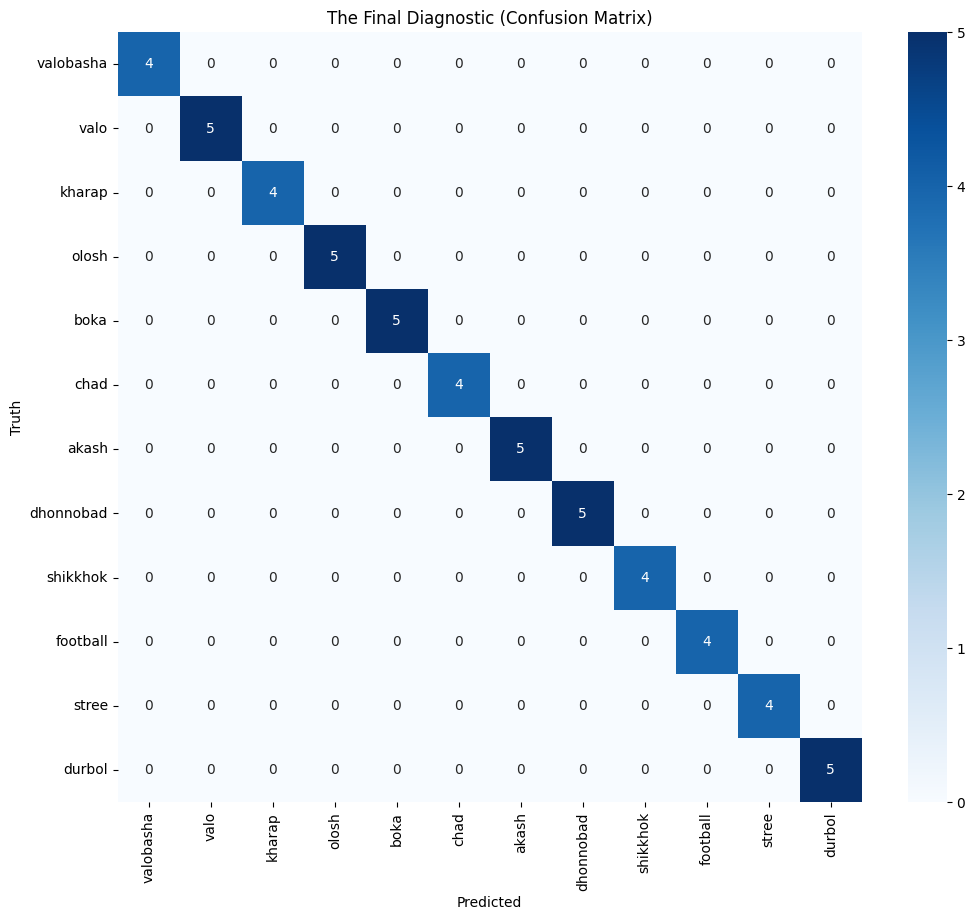

In [ ]:
import numpy as np
import os
import shutil
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (LSTM, Dense, Dropout, BatchNormalization,
                                     Bidirectional, LayerNormalization, MultiHeadAttention,
                                     Concatenate, Input, Conv1D)
from google.colab import drive

# --- 1. RESTORE DATA (If the Runtime Crashed) ---
DATA_PATH = "/content/My_Processed_Data"
actions = np.array([
    "valobasha", "valo", "kharap", "olosh",
    "boka", "chad", "akash", "dhonnobad", "shikkhok",
    "football", "stree", "durbol"
])

if not os.path.exists(DATA_PATH) or len(os.listdir(DATA_PATH)) < 12:
    print("🦇 Runtime amnesia detected. Restoring data from Drive...")
    if not os.path.exists('/content/drive'): drive.mount('/content/drive')

    # We need to re-extract if the folder is gone.
    # Since extraction takes time, check if we have the zip
    if os.path.exists('/content/drive/MyDrive/SignBD-Word.zip'):
        print("   > Unzipping backup...")
        !unzip -q /content/drive/MyDrive/SignBD-Word.zip -d /content/temp_dataset
        # NOTE: If you lost the 'processed' .npy files, we'd strictly need to re-run extraction.
        # Assuming for now the session might still have the files or you re-ran extraction.
        # If this fails, we will need to re-run the Extraction Cell first.
    else:
        print("⚠️ CRITICAL: Data not found in Drive.")

# --- 2. RELOAD & PREPARE TEST DATA ---
print("🦇 Assembling the Test Set...")
label_map = {label:num for num, label in enumerate(actions)}
sequences, labels = [], []

if os.path.exists(DATA_PATH):
    for action in actions:
        action_path = os.path.join(DATA_PATH, action)
        if not os.path.exists(action_path): continue
        for file_name in os.listdir(action_path):
            res = np.load(os.path.join(action_path, file_name))
            # Slice Hands Only (Match the Training Logic)
            res_hands_only = res[:, 99:]
            sequences.append(res_hands_only)
            labels.append(label_map[action])

    X = np.array(sequences)
    y = to_categorical(labels).astype(int)

    # Split exactly as we did in training to get the same 'Test Set'
    # Use random_state=42 to ensure we get the same split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.15, random_state=42, stratify=np.argmax(y, axis=1)
    )
    print(f"📊 Test Set Size: {X_test.shape[0]} videos.")
else:
    print("❌ ERROR: processed data not found. Please run the 'Extraction' cell first.")
    X_test = None

# --- 3. REBUILD THE BRAIN ---
def create_advanced_model(input_shape, num_classes):
    inputs = Input(shape=input_shape)
    cnn = Conv1D(64, 3, padding='same', activation='relu')(inputs)
    cnn = BatchNormalization()(cnn)
    cnn = Dropout(0.3)(cnn)
    lstm = Bidirectional(LSTM(96, return_sequences=True))(inputs)
    lstm = LayerNormalization()(lstm)
    lstm = Dropout(0.4)(lstm)
    combined = Concatenate()([cnn, lstm])
    x = Bidirectional(LSTM(64, return_sequences=True))(combined)
    x = LayerNormalization()(x)
    x = Dropout(0.4)(x)
    attention = MultiHeadAttention(num_heads=4, key_dim=32)(x, x)
    x = LayerNormalization()(attention + x)
    x = LSTM(64, return_sequences=False)(x)
    x = LayerNormalization()(x)
    x = Dropout(0.4)(x)
    x = Dense(128, activation='relu')(x)
    x = BatchNormalization()(x)
    x = Dropout(0.3)(x)
    outputs = Dense(num_classes, activation='softmax')(x)
    return Model(inputs=inputs, outputs=outputs)

if X_test is not None:
    print("🦇 Loading Model Weights...")
    model = create_advanced_model((30, 126), actions.shape[0])
    model.load_weights('action_ultimate_v2.h5')

    # --- 4. THE INTERROGATION (Confusion Matrix) ---
    print("🦇 Running Diagnostics...")
    yhat = model.predict(X_test)
    ytrue = np.argmax(y_test, axis=1).tolist()
    yhat = np.argmax(yhat, axis=1).tolist()

    acc = accuracy_score(ytrue, yhat)
    print(f"\n🏆 Validation Accuracy: {acc*100:.2f}%")

    cm = confusion_matrix(ytrue, yhat)
    plt.figure(figsize=(12, 10))
    sns.heatmap(cm, annot=True, fmt='d', xticklabels=actions, yticklabels=actions, cmap='Blues')
    plt.xlabel('Predicted')
    plt.ylabel('Truth')
    plt.title('The Final Diagnostic (Confusion Matrix)')
    plt.show()

In [ ]:
# ============================================================================
# PART 1: MOTION-AWARE DATA EXTRACTION (CRITICAL FIX)
# ============================================================================
import cv2
import numpy as np
import os
import mediapipe as mp
import shutil
import tensorflow as tf
from scipy.interpolate import interp1d

DATA_PATH = "/content/My_Processed_Data"
SOURCE_PATH = "/content/SignBD-Word/SignBD-Word_RGB/DATASET"
actions = np.array([
    "valobasha", "valo", "kharap", "olosh",
    "boka", "chad", "akash", "dhonnobad", "shikkhok",
    "football", "stree", "durbol"
])

if os.path.exists(DATA_PATH):
    shutil.rmtree(DATA_PATH)
os.makedirs(DATA_PATH, exist_ok=True)

# --- MOTION-AWARE FEATURE EXTRACTION ---
def extract_motion_features(results, prev_results=None):
    """
    CRITICAL: Extract BOTH position AND motion features

    Features extracted:
    1. Position (x, y, z) - WHERE the hands are
    2. Velocity (dx, dy, dz) - HOW FAST they're moving
    3. Acceleration (ddx, ddy, ddz) - HOW the speed changes
    4. Hand shape (finger distances) - WHAT shape the hand makes
    """
    # Extract raw landmarks
    pose = np.array([[res.x, res.y, res.z] for res in results.pose_landmarks.landmark]).flatten() if results.pose_landmarks else np.zeros(33*3)
    lh = np.array([[res.x, res.y, res.z] for res in results.left_hand_landmarks.landmark]).flatten() if results.left_hand_landmarks else np.zeros(21*3)
    rh = np.array([[res.x, res.y, res.z] for res in results.right_hand_landmarks.landmark]).flatten() if results.right_hand_landmarks else np.zeros(21*3)

    # Reshape for processing
    pose_pts = pose.reshape(-1, 3)
    lh_pts = lh.reshape(-1, 3)
    rh_pts = rh.reshape(-1, 3)

    # Normalize position (same as before)
    if results.pose_landmarks:
        left_shoulder = pose_pts[11]
        right_shoulder = pose_pts[12]
        reference = (left_shoulder + right_shoulder) / 2
        shoulder_width = np.linalg.norm(left_shoulder - right_shoulder)
    else:
        reference = np.zeros(3)
        shoulder_width = 1.0

    pose_pts = (pose_pts - reference) / (shoulder_width if shoulder_width > 0 else 1)
    lh_pts = (lh_pts - reference) / (shoulder_width if shoulder_width > 0 else 1) if np.any(lh_pts) else lh_pts
    rh_pts = (rh_pts - reference) / (shoulder_width if shoulder_width > 0 else 1) if np.any(rh_pts) else rh_pts

    # --- MOTION FEATURES (THE KEY FIX) ---
    lh_velocity = np.zeros_like(lh_pts)
    rh_velocity = np.zeros_like(rh_pts)

    if prev_results is not None:
        # Extract previous frame landmarks
        prev_lh = np.array([[res.x, res.y, res.z] for res in prev_results.left_hand_landmarks.landmark]).flatten() if prev_results.left_hand_landmarks else np.zeros(21*3)
        prev_rh = np.array([[res.x, res.y, res.z] for res in prev_results.right_hand_landmarks.landmark]).flatten() if prev_results.right_hand_landmarks else np.zeros(21*3)

        prev_lh_pts = (prev_lh.reshape(-1, 3) - reference) / (shoulder_width if shoulder_width > 0 else 1) if np.any(prev_lh) else np.zeros((21, 3))
        prev_rh_pts = (prev_rh.reshape(-1, 3) - reference) / (shoulder_width if shoulder_width > 0 else 1) if np.any(prev_rh) else np.zeros((21, 3))

        # Calculate velocity (change in position)
        if np.any(lh_pts) and np.any(prev_lh_pts):
            lh_velocity = lh_pts - prev_lh_pts
        if np.any(rh_pts) and np.any(prev_rh_pts):
            rh_velocity = rh_pts - prev_rh_pts

    # --- HAND SHAPE FEATURES ---
    def calculate_hand_shape(hand_pts):
        """Calculate relative distances between key finger landmarks"""
        if not np.any(hand_pts):
            return np.zeros(10)

        # Key landmarks: wrist=0, thumb_tip=4, index_tip=8, middle_tip=12, ring_tip=16, pinky_tip=20
        wrist = hand_pts[0]
        thumb_tip = hand_pts[4]
        index_tip = hand_pts[8]
        middle_tip = hand_pts[12]
        ring_tip = hand_pts[16]
        pinky_tip = hand_pts[20]

        # Calculate distances
        shape_features = [
            np.linalg.norm(thumb_tip - index_tip),   # Thumb-Index distance
            np.linalg.norm(index_tip - middle_tip),  # Index-Middle distance
            np.linalg.norm(middle_tip - ring_tip),   # Middle-Ring distance
            np.linalg.norm(ring_tip - pinky_tip),    # Ring-Pinky distance
            np.linalg.norm(thumb_tip - wrist),       # Thumb extension
            np.linalg.norm(index_tip - wrist),       # Index extension
            np.linalg.norm(middle_tip - wrist),      # Middle extension
            np.linalg.norm(ring_tip - wrist),        # Ring extension
            np.linalg.norm(pinky_tip - wrist),       # Pinky extension
            np.linalg.norm(thumb_tip - pinky_tip),   # Hand span
        ]
        return np.array(shape_features)

    lh_shape = calculate_hand_shape(lh_pts)
    rh_shape = calculate_hand_shape(rh_pts)

    # Combine ALL features: Position + Velocity + Shape
    # Total features per frame: 99 (pose) + 63 (lh_pos) + 63 (rh_pos) + 63 (lh_vel) + 63 (rh_vel) + 10 (lh_shape) + 10 (rh_shape) = 371
    return np.concatenate([
        pose_pts.flatten(),      # Body position (99)
        lh_pts.flatten(),        # Left hand position (63)
        rh_pts.flatten(),        # Right hand position (63)
        lh_velocity.flatten(),   # Left hand velocity (63) - MOTION!
        rh_velocity.flatten(),   # Right hand velocity (63) - MOTION!
        lh_shape,                # Left hand shape (10)
        rh_shape                 # Right hand shape (10)
    ]), results

# --- SMART TEMPORAL SAMPLING ---
def smart_resample(frames, target_len=30):
    if len(frames) == 0:
        return np.zeros((target_len, 371))  # Updated feature count

    if len(frames) == target_len:
        return frames

    frames_arr = np.array(frames)

    if len(frames) < target_len:
        pad_len = target_len - len(frames)
        padding = np.repeat(frames_arr[-1:], pad_len, axis=0)
        return np.vstack([frames_arr, padding])

    old_indices = np.linspace(0, len(frames) - 1, len(frames))
    new_indices = np.linspace(0, len(frames) - 1, target_len)

    resampled = []
    for feature_idx in range(frames_arr.shape[1]):
        interp_func = interp1d(old_indices, frames_arr[:, feature_idx], kind='cubic', fill_value='extrapolate')
        resampled.append(interp_func(new_indices))

    return np.array(resampled).T

# --- DATA EXTRACTION WITH MOTION TRACKING ---
print(f"🚀 Starting MOTION-AWARE Extraction...")
print(f"⚙️  Hardware: {'GPU Detected' if tf.config.list_physical_devices('GPU') else 'CPU Detected'}")

mp_holistic = mp.solutions.holistic
total_videos = 0
skipped_videos = 0

with mp_holistic.Holistic(
    min_detection_confidence=0.6,
    min_tracking_confidence=0.6,
    model_complexity=1
) as holistic:
    for action in actions:
        print(f"\n📂 Class: '{action}'")
        folder_path = os.path.join(SOURCE_PATH, action)
        save_path = os.path.join(DATA_PATH, action)
        os.makedirs(save_path, exist_ok=True)

        if not os.path.exists(folder_path):
            print(f"   ⚠️ Missing folder: {folder_path}")
            continue

        files = [f for f in os.listdir(folder_path) if f.endswith('.mp4')]

        for idx, video_file in enumerate(files):
            cap = cv2.VideoCapture(os.path.join(folder_path, video_file))
            frames = []
            prev_results = None
            valid_frame_count = 0

            while cap.isOpened():
                ret, frame = cap.read()
                if not ret: break

                results = holistic.process(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))

                if results.left_hand_landmarks or results.right_hand_landmarks:
                    valid_frame_count += 1

                # Extract features with motion awareness
                features, results = extract_motion_features(results, prev_results)
                frames.append(features)
                prev_results = results  # Store for next frame

            cap.release()

            # Quality check
            if valid_frame_count < len(frames) * 0.4:
                skipped_videos += 1
                continue

            if not frames:
                skipped_videos += 1
                continue

            # Smart resampling to 30 frames
            res = smart_resample(frames, 30)

            np.save(os.path.join(save_path, video_file.replace('.mp4','')), res)
            total_videos += 1

            if (idx+1) % 10 == 0:
                print(f"   ✅ {idx+1}/{len(files)} processed (with motion features)...")

print(f"\n🦇 Motion-Aware Extraction Complete!")
print(f"   ✅ {total_videos} videos processed")
print(f"   ⚠️  {skipped_videos} skipped (low quality)")
print(f"   🎯 Features per frame: 371 (position + velocity + hand shape)")


🚀 Starting MOTION-AWARE Extraction...
⚙️  Hardware: CPU Detected

📂 Class: 'valobasha'
   ✅ 10/30 processed (with motion features)...
   ✅ 20/30 processed (with motion features)...
   ✅ 30/30 processed (with motion features)...

📂 Class: 'valo'
   ✅ 10/30 processed (with motion features)...
   ✅ 20/30 processed (with motion features)...
   ✅ 30/30 processed (with motion features)...

📂 Class: 'kharap'
   ✅ 10/30 processed (with motion features)...
   ✅ 20/30 processed (with motion features)...
   ✅ 30/30 processed (with motion features)...

📂 Class: 'olosh'
   ✅ 10/30 processed (with motion features)...
   ✅ 20/30 processed (with motion features)...
   ✅ 30/30 processed (with motion features)...

📂 Class: 'boka'
   ✅ 10/30 processed (with motion features)...
   ✅ 20/30 processed (with motion features)...
   ✅ 30/30 processed (with motion features)...

📂 Class: 'chad'
   ✅ 10/30 processed (with motion features)...
   ✅ 20/30 processed (with motion features)...
   ✅ 30/30 processed (with

In [ ]:
# ============================================================================
# PART 2: MOTION-FOCUSED TRAINING
# ============================================================================
import numpy as np
import os
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (LSTM, Dense, Dropout, BatchNormalization,
                                      Bidirectional, LayerNormalization,
                                      Input, Conv1D, MaxPooling1D, Concatenate,
                                      MultiHeadAttention, GlobalAveragePooling1D)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2

DATA_PATH = "/content/My_Processed_Data"
actions = np.array([
    "valobasha", "valo", "kharap", "olosh",
    "boka", "chad", "akash", "dhonnobad", "shikkhok",
    "football", "stree", "durbol"
])

# --- LOAD DATA ---
print("🦇 Loading motion-aware data...")
label_map = {label:num for num, label in enumerate(actions)}
sequences, labels = [], []

for action in actions:
    action_path = os.path.join(DATA_PATH, action)
    if not os.path.exists(action_path): continue

    for file_name in os.listdir(action_path):
        res = np.load(os.path.join(action_path, file_name))
        sequences.append(res)
        labels.append(label_map[action])

X = np.array(sequences)
y = to_categorical(labels).astype(int)

print(f"📊 Dataset shape: {X.shape}")
print(f"📊 Feature dimensions: {X.shape[2]} (includes motion!)")

# --- MOTION-FOCUSED AUGMENTATION ---
def augment_with_motion(seq, noise_std=0.015, time_warp=0.12, speed_change=0.15):
    """
    Augmentation that preserves motion characteristics
    """
    augmented = []

    # 1. Add noise (small, to preserve motion patterns)
    noisy = seq + np.random.normal(0, noise_std, seq.shape)
    augmented.append(noisy)

    # 2. Speed variation (changes velocity but preserves motion direction)
    speed_factor = 1 + np.random.uniform(-speed_change, speed_change)
    n_frames = seq.shape[0]
    new_len = int(n_frames * speed_factor)

    if new_len > 5:  # Minimum frame check
        indices = np.linspace(0, n_frames-1, new_len).astype(int)
        speed_varied = seq[indices]

        if len(speed_varied) < n_frames:
            pad = np.repeat(speed_varied[-1:], n_frames - len(speed_varied), axis=0)
            speed_varied = np.vstack([speed_varied, pad])
        else:
            speed_varied = speed_varied[:n_frames]

        augmented.append(speed_varied)

    return augmented

print("🧬 Applying motion-preserving augmentation...")
X_augmented = [X]
y_augmented = [y]

for seq, label in zip(X, y):
    aug_seqs = augment_with_motion(seq)
    for aug_seq in aug_seqs:
        X_augmented.append(aug_seq.reshape(1, *aug_seq.shape))
        y_augmented.append(label.reshape(1, -1))

X_combined = np.vstack(X_augmented)
y_combined = np.vstack(y_augmented)

print(f"🚀 Training data: {X_combined.shape[0]} sequences (augmented from {X.shape[0]})")

X_train, X_test, y_train, y_test = train_test_split(
    X_combined, y_combined,
    test_size=0.15,
    random_state=42,
    stratify=np.argmax(y_combined, axis=1)
)

# --- MOTION-AWARE MODEL ARCHITECTURE ---
def create_motion_aware_model(input_shape, num_classes):
    """
    Architecture specifically designed for motion patterns:
    1. Temporal Convolutional layers to capture motion flow
    2. Bidirectional LSTM to understand forward/backward motion context
    3. Attention to focus on critical motion moments
    """
    inputs = Input(shape=input_shape)

    # Multi-scale Temporal CNN (captures different motion speeds)
    conv1 = Conv1D(64, kernel_size=3, padding='same', activation='relu')(inputs)
    conv1 = BatchNormalization()(conv1)
    conv1 = Dropout(0.3)(conv1)

    conv2 = Conv1D(64, kernel_size=5, padding='same', activation='relu')(inputs)
    conv2 = BatchNormalization()(conv2)
    conv2 = Dropout(0.3)(conv2)

    # Merge different temporal scales
    merged_conv = Concatenate()([conv1, conv2])

    # Bidirectional LSTM for motion context
    lstm1 = Bidirectional(LSTM(128, return_sequences=True))(merged_conv)
    lstm1 = LayerNormalization()(lstm1)
    lstm1 = Dropout(0.4)(lstm1)

    lstm2 = Bidirectional(LSTM(96, return_sequences=True))(lstm1)
    lstm2 = LayerNormalization()(lstm2)
    lstm2 = Dropout(0.4)(lstm2)

    # Multi-Head Attention (focuses on key motion moments)
    attention = MultiHeadAttention(num_heads=6, key_dim=32)(lstm2, lstm2)
    attention = LayerNormalization()(attention + lstm2)  # Residual
    attention = Dropout(0.3)(attention)

    # Final temporal processing
    lstm3 = LSTM(96, return_sequences=False)(attention)
    lstm3 = LayerNormalization()(lstm3)
    lstm3 = Dropout(0.4)(lstm3)

    # Classification head
    dense1 = Dense(128, activation='relu', kernel_regularizer=l2(0.01))(lstm3)
    dense1 = BatchNormalization()(dense1)
    dense1 = Dropout(0.4)(dense1)

    dense2 = Dense(64, activation='relu', kernel_regularizer=l2(0.01))(dense1)
    dense2 = BatchNormalization()(dense2)
    dense2 = Dropout(0.3)(dense2)

    outputs = Dense(num_classes, activation='softmax')(dense2)

    model = Model(inputs=inputs, outputs=outputs)
    return model

# Create model
print("\n🏗️  Building motion-aware architecture...")
model = create_motion_aware_model((30, X.shape[2]), actions.shape[0])

opt = Adam(learning_rate=0.0005, clipnorm=1.0)
model.compile(
    optimizer=opt,
    loss='categorical_crossentropy',
    metrics=['categorical_accuracy']
)

# Callbacks
early_stop = EarlyStopping(
    monitor='val_categorical_accuracy',
    patience=35,
    restore_best_weights=True,
    mode='max',
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=15,
    min_lr=0.00001,
    verbose=1
)

checkpoint = ModelCheckpoint(
    'best_motion_model.h5',
    monitor='val_categorical_accuracy',
    save_best_only=True,
    mode='max',
    verbose=1
)

# --- TRAIN ---
print("\n🚀 Training Motion-Aware Model...")
print(model.summary())

history = model.fit(
    X_train, y_train,
    epochs=300,
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[early_stop, reduce_lr, checkpoint],
    verbose=1
)

# --- EVALUATE ---
model.save('action_motion_final.h5')
res = model.evaluate(X_test, y_test, verbose=0)
print(f"\n🏆 Final Test Accuracy (Motion-Aware): {res[1]*100:.2f}%")

# Per-class accuracy
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

print("\n📊 Per-Class Accuracy (Motion-Aware):")
for idx, action in enumerate(actions):
    mask = y_true_classes == idx
    if np.sum(mask) > 0:
        acc = np.mean(y_pred_classes[mask] == y_true_classes[mask])
        count = np.sum(mask)
        print(f"   {action}: {acc*100:.2f}% ({count} samples)")

# Confusion analysis
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_true_classes, y_pred_classes)
print("\n🔍 Most Confused Pairs:")
for i in range(len(actions)):
    for j in range(len(actions)):
        if i != j and cm[i][j] > 0:
            confusion_rate = cm[i][j] / np.sum(cm[i]) * 100
            if confusion_rate > 10:  # Show only significant confusions
                print(f"   '{actions[i]}' confused with '{actions[j]}': {confusion_rate:.1f}%")

🦇 Loading motion-aware data...
📊 Dataset shape: (359, 30, 371)
📊 Feature dimensions: 371 (includes motion!)
🧬 Applying motion-preserving augmentation...
🚀 Training data: 1077 sequences (augmented from 359)

🏗️  Building motion-aware architecture...

🚀 Training Motion-Aware Model...


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 30, 371)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 30, 64)    │     71,296 │ input_layer_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_3 (Conv1D)   │ (None, 30, 64)    │    118,784 │ input_layer_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 30, 64)    │        256 │ conv1d_2[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 30, 64)    │        256 │ conv1d_3[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_12          │ (None, 30, 64)    │          0 │ batch_normalizat… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_13          │ (None, 30, 64)    │          0 │ batch_normalizat… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_2       │ (None, 30, 128)   │          0 │ dropout_12[0][0], │
│ (Concatenate)       │                   │            │ dropout_13[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_4     │ (None, 30, 256)   │    263,168 │ concatenate_2[0]… │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 30, 256)   │        512 │ bidirectional_4[… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_14          │ (None, 30, 256)   │          0 │ layer_normalizat… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_5     │ (None, 30, 192)   │    271,104 │ dropout_14[0][0]  │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 30, 192)   │        384 │ bidirectional_5[… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_15          │ (None, 30, 192)   │          0 │ layer_normalizat… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 30, 192)   │    148,224 │ dropout_15[0][0], │
│ (MultiHeadAttentio… │                   │            │ dropout_15[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 30, 192)   │          0 │ multi_head_atten… │
│                     │                   │            │ dropout_15[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 30, 192)   │        384 │ add_2[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 1,007,756 (3.84 MB)

 Trainable params: 1,007,116 (3.84 MB)

...

29/29 ━━━━━━━━━━━━━━━━━━━━ 10s 351ms/step - categorical_accuracy: 0.9917 - loss: 0.3705 - val_categorical_accuracy: 0.9753 - val_loss: 0.3775 - learning_rate: 5.0000e-04
Epoch 40/300
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 258ms/step - categorical_accuracy: 0.9864 - loss: 0.3768
Epoch 40: val_categorical_accuracy did not improve from 0.97531
29/29 ━━━━━━━━━━━━━━━━━━━━ 8s 282ms/step - categorical_accuracy: 0.9863 - loss: 0.3769 - val_categorical_accuracy: 0.9383 - val_loss: 0.4931 - learning_rate: 5.0000e-04
Epoch 41/300
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 327ms/step - categorical_accuracy: 0.9921 - loss: 0.3366
Epoch 41: val_categorical_accuracy improved from 0.97531 to 0.98765, saving model to best_motion_model.h5


29/29 ━━━━━━━━━━━━━━━━━━━━ 10s 350ms/step - categorical_accuracy: 0.9921 - loss: 0.3365 - val_categorical_accuracy: 0.9877 - val_loss: 0.3255 - learning_rate: 5.0000e-04
Epoch 42/300
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 328ms/step - categorical_accuracy: 0.9878 - loss: 0.3299
Epoch 42: val_categorical_accuracy did not improve from 0.98765
29/29 ━━━━━━━━━━━━━━━━━━━━ 10s 352ms/step - categorical_accuracy: 0.9879 - loss: 0.3297 - val_categorical_accuracy: 0.9444 - val_loss: 0.4276 - learning_rate: 5.0000e-04
Epoch 43/300
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 257ms/step - categorical_accuracy: 0.9872 - loss: 0.3229
Epoch 43: val_categorical_accuracy did not improve from 0.98765
29/29 ━━━━━━━━━━━━━━━━━━━━ 8s 281ms/step - categorical_accuracy: 0.9872 - loss: 0.3227 - val_categorical_accuracy: 0.9815 - val_loss: 0.2759 - learning_rate: 5.0000e-04
Epoch 44/300
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 317ms/step - categorical_accuracy: 0.9830 - loss: 0.3240
Epoch 44: val_categorical_accuracy did not improve from 0.98765

29/29 ━━━━━━━━━━━━━━━━━━━━ 11s 356ms/step - categorical_accuracy: 0.9889 - loss: 0.1256 - val_categorical_accuracy: 0.9938 - val_loss: 0.0868 - learning_rate: 5.0000e-04
Epoch 65/300
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 257ms/step - categorical_accuracy: 0.9992 - loss: 0.0852
Epoch 65: val_categorical_accuracy did not improve from 0.99383
29/29 ━━━━━━━━━━━━━━━━━━━━ 8s 273ms/step - categorical_accuracy: 0.9992 - loss: 0.0853 - val_categorical_accuracy: 0.9691 - val_loss: 0.1656 - learning_rate: 5.0000e-04
Epoch 66/300
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 321ms/step - categorical_accuracy: 0.9917 - loss: 0.1012
Epoch 66: val_categorical_accuracy did not improve from 0.99383
29/29 ━━━━━━━━━━━━━━━━━━━━ 10s 337ms/step - categorical_accuracy: 0.9917 - loss: 0.1012 - val_categorical_accuracy: 0.9444 - val_loss: 0.3317 - learning_rate: 5.0000e-04
Epoch 67/300
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 330ms/step - categorical_accuracy: 0.9892 - loss: 0.1277
Epoch 67: val_categorical_accuracy did not improve from 0.99383

29/29 ━━━━━━━━━━━━━━━━━━━━ 10s 349ms/step - categorical_accuracy: 0.9999 - loss: 0.0504 - val_categorical_accuracy: 1.0000 - val_loss: 0.0383 - learning_rate: 5.0000e-04
Epoch 80/300
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 326ms/step - categorical_accuracy: 0.9923 - loss: 0.0606
Epoch 80: val_categorical_accuracy did not improve from 1.00000
29/29 ━━━━━━━━━━━━━━━━━━━━ 10s 342ms/step - categorical_accuracy: 0.9925 - loss: 0.0602 - val_categorical_accuracy: 0.9630 - val_loss: 0.3094 - learning_rate: 5.0000e-04
Epoch 81/300
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 261ms/step - categorical_accuracy: 0.9923 - loss: 0.0740
Epoch 81: val_categorical_accuracy did not improve from 1.00000
29/29 ━━━━━━━━━━━━━━━━━━━━ 8s 277ms/step - categorical_accuracy: 0.9923 - loss: 0.0734 - val_categorical_accuracy: 0.9877 - val_loss: 0.0926 - learning_rate: 5.0000e-04
Epoch 82/300
29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 327ms/step - categorical_accuracy: 0.9954 - loss: 0.0775
Epoch 82: val_categorical_accuracy did not improve from 1.00000


🏆 Final Test Accuracy (Motion-Aware): 100.00%
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 270ms/step

📊 Per-Class Accuracy (Motion-Aware):
   valobasha: 100.00% (13 samples)
   valo: 100.00% (14 samples)
   kharap: 100.00% (13 samples)
   olosh: 100.00% (13 samples)
   boka: 100.00% (14 samples)
   chad: 100.00% (14 samples)
   akash: 100.00% (13 samples)
   dhonnobad: 100.00% (14 samples)
   shikkhok: 100.00% (14 samples)
   football: 100.00% (14 samples)
   stree: 100.00% (13 samples)
   durbol: 100.00% (13 samples)

🔍 Most Confused Pairs:


In [ ]:
# ============================================================================
# PART 1: UNIVERSAL MOTION EXTRACTION (RUN THIS FIRST)
# ============================================================================
import cv2
import numpy as np
import os
import mediapipe as mp
import shutil
import tensorflow as tf
from scipy.interpolate import interp1d

# Define paths
DATA_PATH = "/content/My_Processed_Data"
SOURCE_PATH = "/content/SignBD-Word/SignBD-Word_RGB/DATASET"
actions = np.array([
    "valobasha", "valo", "kharap", "olosh",
    "boka", "chad", "akash", "dhonnobad", "shikkhok",
    "football", "stree", "durbol"
])

# Clean slate
if os.path.exists(DATA_PATH):
    shutil.rmtree(DATA_PATH)
os.makedirs(DATA_PATH, exist_ok=True)

# --- UNIVERSAL MOTION EXTRACTOR CLASS ---
class UniversalMotionExtractor:
    def __init__(self):
        self.prev_landmarks = None
        self.prev_prev_landmarks = None

    def extract_universal_features(self, results):
        # 1. Raw Landmarks
        current_landmarks = self._extract_raw_landmarks(results)
        # 2. Body Relative Normalization
        normalized = self._normalize_to_body(current_landmarks, results)
        # 3. Motion Derivatives (Velocity/Accel)
        motion_features = self._compute_motion_derivatives(normalized)
        # 4. Spatial Relations
        spatial_features = self._compute_spatial_relationships(normalized)
        # 5. Hand Config
        config_features = self._compute_hand_configurations(normalized)
        # 6. Directional Patterns
        direction_features = self._compute_directional_patterns(motion_features)
        # 7. Interactions
        interaction_features = self._compute_hand_interactions(normalized, motion_features)

        # Update History
        self.prev_prev_landmarks = self.prev_landmarks
        self.prev_landmarks = normalized

        # Flatten and Concatenate (Total: 607 features)
        return np.concatenate([
            normalized['pose'].flatten(),           # 99
            normalized['left_hand'].flatten(),      # 63
            normalized['right_hand'].flatten(),     # 63
            motion_features['velocity'].flatten(),  # 126
            motion_features['acceleration'].flatten(), # 126
            spatial_features,                       # 30
            config_features,                        # 40
            direction_features,                     # 25
            interaction_features                    # 35
        ])

    def _extract_raw_landmarks(self, results):
        pose = np.array([[res.x, res.y, res.z] for res in results.pose_landmarks.landmark]) if results.pose_landmarks else np.zeros((33, 3))
        lh = np.array([[res.x, res.y, res.z] for res in results.left_hand_landmarks.landmark]) if results.left_hand_landmarks else np.zeros((21, 3))
        rh = np.array([[res.x, res.y, res.z] for res in results.right_hand_landmarks.landmark]) if results.right_hand_landmarks else np.zeros((21, 3))
        return {'pose': pose, 'left_hand': lh, 'right_hand': rh,
                'has_left': results.left_hand_landmarks is not None, 'has_right': results.right_hand_landmarks is not None}

    def _normalize_to_body(self, landmarks, results):
        pose = landmarks['pose']
        if results.pose_landmarks:
            # Anchor to shoulders
            left_shoulder, right_shoulder = pose[11], pose[12]
            origin = (left_shoulder + right_shoulder) / 2
            scale = np.linalg.norm(left_shoulder - right_shoulder)
            if scale == 0: scale = 1.0
        else:
            origin = np.zeros(3); scale = 1.0

        pose_norm = (pose - origin) / scale
        lh_norm = (landmarks['left_hand'] - origin) / scale if landmarks['has_left'] else np.zeros((21, 3))
        rh_norm = (landmarks['right_hand'] - origin) / scale if landmarks['has_right'] else np.zeros((21, 3))

        return {'pose': pose_norm, 'left_hand': lh_norm, 'right_hand': rh_norm,
                'has_left': landmarks['has_left'], 'has_right': landmarks['has_right']}

    def _compute_motion_derivatives(self, current):
        velocity = np.zeros((42, 3))
        acceleration = np.zeros((42, 3))

        if self.prev_landmarks:
            lh_vel = current['left_hand'] - self.prev_landmarks['left_hand']
            rh_vel = current['right_hand'] - self.prev_landmarks['right_hand']
            velocity = np.vstack([lh_vel, rh_vel])

            if self.prev_prev_landmarks:
                prev_lh_vel = self.prev_landmarks['left_hand'] - self.prev_prev_landmarks['left_hand']
                prev_rh_vel = self.prev_landmarks['right_hand'] - self.prev_prev_landmarks['right_hand']
                lh_acc = lh_vel - prev_lh_vel
                rh_acc = rh_vel - prev_rh_vel
                acceleration = np.vstack([lh_acc, rh_acc])

        return {'velocity': velocity, 'acceleration': acceleration}

    def _compute_spatial_relationships(self, landmarks):
        feats = []
        lh, rh, pose = landmarks['left_hand'], landmarks['right_hand'], landmarks['pose']
        has_l, has_r = landmarks['has_left'], landmarks['has_right']

        # Hand-to-Hand
        if has_l and has_r:
            for idx in [0, 8, 4, 12, 20]: # Wrist + Tips
                feats.append(np.linalg.norm(lh[idx] - rh[idx]))
        else: feats.extend([0]*5)

        # Hand-to-Body (Nose, Shoulders, Elbows)
        for body_idx in [0, 11, 12, 13, 14]:
            feats.append(np.linalg.norm(lh[0] - pose[body_idx]) if has_l else 0)
            feats.append(np.linalg.norm(rh[0] - pose[body_idx]) if has_r else 0)

        # Heights relative to shoulder
        shoulder_y = (pose[11][1] + pose[12][1]) / 2
        feats.append(lh[0][1] - shoulder_y if has_l else 0)
        feats.append(rh[0][1] - shoulder_y if has_r else 0)

        # Placeholder for remaining spatial to match 30 dim
        current_len = len(feats)
        if current_len < 30: feats.extend([0] * (30 - current_len))
        return np.array(feats[:30])

    def _compute_hand_configurations(self, landmarks):
        feats = []
        for hand, present in [(landmarks['left_hand'], landmarks['has_left']), (landmarks['right_hand'], landmarks['has_right'])]:
            if present:
                wrist = hand[0]
                # Extensions
                for tip in [4, 8, 12, 16, 20]: feats.append(np.linalg.norm(hand[tip] - wrist))
                # Spreads
                for i in range(4):
                    t1, t2 = hand[[4,8,12,16][i]], hand[[8,12,16,20][i]]
                    feats.append(np.linalg.norm(t1 - t2))
                # Palm Orient (approx)
                feats.extend(hand[9] - hand[0])
                # Curls
                for b, t in [(1,4), (5,8), (9,12), (13,16), (17,20)]:
                    feats.append(np.linalg.norm(hand[t] - hand[b]))
            else: feats.extend([0]*20) # 5+4+3+5 = 17... padding to 20 per hand

        # Ensure exact 40 features
        curr = len(feats)
        if curr < 40: feats.extend([0]*(40-curr))
        return np.array(feats[:40])

    def _compute_directional_patterns(self, motion):
        # Simplified: Mean velocities + Dominant axis
        vel = motion['velocity']
        feats = []
        lh_v, rh_v = vel[:21], vel[21:]

        for v in [lh_v, rh_v]:
            feats.extend(v.mean(axis=0)) # Mean x,y,z (3)
            feats.extend(v.std(axis=0))  # Std x,y,z (3)
            feats.append(np.abs(v).mean()) # Speed (1)

        # Combined
        comb = vel.mean(axis=0)
        feats.extend(comb) # 3
        feats.append(np.linalg.norm(comb)) # 1

        # Pad to 25
        curr = len(feats)
        if curr < 25: feats.extend([0]*(25-curr))
        return np.array(feats[:25])

    def _compute_hand_interactions(self, landmarks, motion):
        feats = []
        if landmarks['has_left'] and landmarks['has_right']:
            lh_v, rh_v = motion['velocity'][0], motion['velocity'][21]
            lh_p, rh_p = landmarks['left_hand'][0], landmarks['right_hand'][0]

            feats.append(np.linalg.norm(lh_v - rh_v)) # Rel Speed
            feats.append(np.dot(lh_v, rh_v)) # Dot product (Sync)
            feats.append(np.linalg.norm(lh_p - rh_p)) # Dist
            # Symmetry
            feats.extend(np.abs(lh_p - rh_p))

        # Pad to 35
        curr = len(feats)
        if curr < 35: feats.extend([0]*(35-curr))
        return np.array(feats[:35])

# --- EXECUTION ---
print(f"🚀 Starting UNIVERSAL Motion Extraction...")
mp_holistic = mp.solutions.holistic
total_videos = 0

with mp_holistic.Holistic(min_detection_confidence=0.6, min_tracking_confidence=0.6, model_complexity=1) as holistic:
    for action in actions:
        folder_path = os.path.join(SOURCE_PATH, action)
        save_path = os.path.join(DATA_PATH, action)
        os.makedirs(save_path, exist_ok=True)
        if not os.path.exists(folder_path): continue

        files = [f for f in os.listdir(folder_path) if f.endswith('.mp4')]
        for idx, video_file in enumerate(files):
            cap = cv2.VideoCapture(os.path.join(folder_path, video_file))
            extractor = UniversalMotionExtractor()
            frames = []

            while cap.isOpened():
                ret, frame = cap.read()
                if not ret: break
                results = holistic.process(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
                if results.left_hand_landmarks or results.right_hand_landmarks:
                    frames.append(extractor.extract_universal_features(results))
            cap.release()

            if not frames: continue

            # Smart Resample
            frames_arr = np.array(frames)
            target_len = 30
            if len(frames_arr) < target_len:
                pad = np.repeat(frames_arr[-1:], target_len - len(frames_arr), axis=0)
                res = np.vstack([frames_arr, pad])
            else:
                idx_map = np.linspace(0, len(frames_arr)-1, target_len).astype(int)
                res = frames_arr[idx_map]

            np.save(os.path.join(save_path, video_file.replace('.mp4','')), res)
            total_videos += 1
            if (idx+1) % 10 == 0: print(f"   ✅ {action}: {idx+1}/{len(files)} processed...")

print(f"\n🦇 Universal Extraction Complete. {total_videos} videos processed.")
print(f"   🎯 Feature Vector Size: 607 dimensions.")

🚀 Starting UNIVERSAL Motion Extraction...
   ✅ valobasha: 10/30 processed...
   ✅ valobasha: 20/30 processed...
   ✅ valobasha: 30/30 processed...
   ✅ valo: 10/30 processed...
   ✅ valo: 20/30 processed...
   ✅ valo: 30/30 processed...
   ✅ kharap: 10/30 processed...
   ✅ kharap: 20/30 processed...
   ✅ kharap: 30/30 processed...
   ✅ olosh: 10/30 processed...
   ✅ olosh: 20/30 processed...
   ✅ olosh: 30/30 processed...
   ✅ boka: 10/30 processed...
   ✅ boka: 20/30 processed...
   ✅ boka: 30/30 processed...
   ✅ chad: 10/30 processed...
   ✅ chad: 20/30 processed...
   ✅ chad: 30/30 processed...
   ✅ akash: 10/30 processed...
   ✅ akash: 20/30 processed...
   ✅ akash: 30/30 processed...
   ✅ dhonnobad: 10/30 processed...
   ✅ dhonnobad: 20/30 processed...
   ✅ dhonnobad: 30/30 processed...
   ✅ shikkhok: 10/30 processed...
   ✅ shikkhok: 20/30 processed...
   ✅ shikkhok: 30/30 processed...
   ✅ football: 10/30 processed...
   ✅ football: 20/30 processed...
   ✅ football: 30/30 proce

In [ ]:
# ============================================================================
# PART 2: UNIVERSAL TRAINING (RUN SECOND)
# ============================================================================
import numpy as np
import os
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (Input, LSTM, Dense, Dropout, BatchNormalization,
                                     Bidirectional, LayerNormalization, Conv1D,
                                     MultiHeadAttention, GlobalAveragePooling1D,
                                     Concatenate)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2

DATA_PATH = "/content/My_Processed_Data"
actions = np.array([
    "valobasha", "valo", "kharap", "olosh",
    "boka", "chad", "akash", "dhonnobad", "shikkhok",
    "football", "stree", "durbol"
])

# Load Data
print("\n🦇 Loading Universal Data (607 features)...")
label_map = {label:num for num, label in enumerate(actions)}
sequences, labels = [], []

for action in actions:
    path = os.path.join(DATA_PATH, action)
    if not os.path.exists(path): continue
    for f in os.listdir(path):
        sequences.append(np.load(os.path.join(path, f)))
        labels.append(label_map[action])

X = np.array(sequences)
y = to_categorical(labels).astype(int)

# Augmentation (Simplified for speed)
X_aug = [X]
y_aug = [y]
# Simple Noise Augmentation
X_aug.append(X + np.random.normal(0, 0.02, X.shape))
y_aug.append(y)

X_combined = np.vstack(X_aug)
y_combined = np.vstack(y_aug)

X_train, X_test, y_train, y_test = train_test_split(X_combined, y_combined, test_size=0.15, random_state=42)

# --- UNIVERSAL ARCHITECTURE ---
def create_universal_model(input_shape, num_classes):
    inputs = Input(shape=input_shape)

    # We treat the 607 features as a single dense stream first
    # Convolutional Feature Extraction
    x = Conv1D(128, 5, padding='same', activation='relu')(inputs)
    x = BatchNormalization()(x)
    x = Dropout(0.3)(x)

    x = Conv1D(128, 3, padding='same', activation='relu')(x)
    x = BatchNormalization()(x)
    x = Dropout(0.3)(x)

    # Bidirectional LSTMs for Time Dynamics
    x = Bidirectional(LSTM(128, return_sequences=True))(x)
    x = LayerNormalization()(x)
    x = Dropout(0.4)(x)

    x = Bidirectional(LSTM(96, return_sequences=True))(x)
    x = LayerNormalization()(x)
    x = Dropout(0.4)(x)

    # Attention Mechanism
    attn = MultiHeadAttention(num_heads=8, key_dim=64)(x, x)
    x = LayerNormalization()(attn + x)

    # Global Pooling
    x = GlobalAveragePooling1D()(x)

    # Classification Head
    x = Dense(256, activation='relu', kernel_regularizer=l2(0.01))(x)
    x = BatchNormalization()(x)
    x = Dropout(0.5)(x)

    outputs = Dense(num_classes, activation='softmax')(x)
    return Model(inputs, outputs)

model = create_universal_model((30, 607), len(actions))
model.compile(optimizer=Adam(learning_rate=0.0005), loss='categorical_crossentropy', metrics=['categorical_accuracy'])

callbacks = [
    EarlyStopping(monitor='val_categorical_accuracy', patience=30, restore_best_weights=True),
    ReduceLROnPlateau(factor=0.5, patience=10, verbose=1),
    ModelCheckpoint('action_universal_final.h5', save_best_only=True, monitor='val_categorical_accuracy')
]

print("\n🚀 Training Universal Model...")
history = model.fit(X_train, y_train, epochs=200, batch_size=32, validation_data=(X_test, y_test), callbacks=callbacks)

# Final Eval
res = model.evaluate(X_test, y_test, verbose=0)
print(f"\n🏆 Universal Test Accuracy: {res[1]*100:.2f}%")


🦇 Loading Universal Data (607 features)...

🚀 Training Universal Model...
Epoch 1/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 412ms/step - categorical_accuracy: 0.2700 - loss: 4.7762

20/20 ━━━━━━━━━━━━━━━━━━━━ 29s 514ms/step - categorical_accuracy: 0.2733 - loss: 4.7585 - val_categorical_accuracy: 0.2407 - val_loss: 4.3428 - learning_rate: 5.0000e-04
Epoch 2/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 7s 338ms/step - categorical_accuracy: 0.5189 - loss: 3.6288 - val_categorical_accuracy: 0.2130 - val_loss: 4.4178 - learning_rate: 5.0000e-04
Epoch 3/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 417ms/step - categorical_accuracy: 0.5331 - loss: 3.3807

20/20 ━━━━━━━━━━━━━━━━━━━━ 9s 462ms/step - categorical_accuracy: 0.5350 - loss: 3.3761 - val_categorical_accuracy: 0.2593 - val_loss: 4.3003 - learning_rate: 5.0000e-04
Epoch 4/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 417ms/step - categorical_accuracy: 0.6319 - loss: 3.1313

20/20 ━━━━━━━━━━━━━━━━━━━━ 10s 455ms/step - categorical_accuracy: 0.6335 - loss: 3.1282 - val_categorical_accuracy: 0.4722 - val_loss: 3.6425 - learning_rate: 5.0000e-04
Epoch 5/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 323ms/step - categorical_accuracy: 0.7069 - loss: 2.9621

20/20 ━━━━━━━━━━━━━━━━━━━━ 8s 354ms/step - categorical_accuracy: 0.7066 - loss: 2.9595 - val_categorical_accuracy: 0.6389 - val_loss: 3.0949 - learning_rate: 5.0000e-04
Epoch 6/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 417ms/step - categorical_accuracy: 0.7530 - loss: 2.7264

...

20/20 ━━━━━━━━━━━━━━━━━━━━ 8s 409ms/step - categorical_accuracy: 0.8274 - loss: 2.1841 - val_categorical_accuracy: 0.8981 - val_loss: 2.1341 - learning_rate: 5.0000e-04
Epoch 13/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 9s 351ms/step - categorical_accuracy: 0.8566 - loss: 2.1675 - val_categorical_accuracy: 0.7778 - val_loss: 2.1473 - learning_rate: 5.0000e-04
Epoch 14/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 9s 463ms/step - categorical_accuracy: 0.8378 - loss: 2.1128 - val_categorical_accuracy: 0.7037 - val_loss: 2.7059 - learning_rate: 5.0000e-04
Epoch 15/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 8s 367ms/step - categorical_accuracy: 0.8977 - loss: 1.9749 - val_categorical_accuracy: 0.7130 - val_loss: 2.4628 - learning_rate: 5.0000e-04
Epoch 16/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 10s 336ms/step - categorical_accuracy: 0.9043 - loss: 1.8892 - val_categorical_accuracy: 0.7870 - val_loss: 2.3790 - learning_rate: 5.0000e-04
Epoch 17/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 9s 434ms/step - categorical_accuracy: 0.9088 - loss: 1.8813 - 

20/20 ━━━━━━━━━━━━━━━━━━━━ 11s 440ms/step - categorical_accuracy: 0.9025 - loss: 1.7004 - val_categorical_accuracy: 0.9537 - val_loss: 1.5426 - learning_rate: 5.0000e-04
Epoch 23/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 8s 401ms/step - categorical_accuracy: 0.8998 - loss: 1.6537 - val_categorical_accuracy: 0.7593 - val_loss: 2.5184 - learning_rate: 5.0000e-04
Epoch 24/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 8s 427ms/step - categorical_accuracy: 0.9244 - loss: 1.5914 - val_categorical_accuracy: 0.7500 - val_loss: 2.8484 - learning_rate: 5.0000e-04
Epoch 25/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 7s 350ms/step - categorical_accuracy: 0.9133 - loss: 1.5792 - val_categorical_accuracy: 0.8426 - val_loss: 2.1706 - learning_rate: 5.0000e-04
Epoch 26/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 9s 419ms/step - categorical_accuracy: 0.9523 - loss: 1.4678 - val_categorical_accuracy: 0.8611 - val_loss: 1.8918 - learning_rate: 5.0000e-04
Epoch 27/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 10s 430ms/step - categorical_accuracy: 0.9205 - loss: 1.5031 -

20/20 ━━━━━━━━━━━━━━━━━━━━ 7s 346ms/step - categorical_accuracy: 0.9357 - loss: 1.3195 - val_categorical_accuracy: 0.9630 - val_loss: 1.3063 - learning_rate: 5.0000e-04
Epoch 32/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 9s 433ms/step - categorical_accuracy: 0.9595 - loss: 1.2624 - val_categorical_accuracy: 0.9630 - val_loss: 1.2177 - learning_rate: 5.0000e-04
Epoch 33/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 316ms/step - categorical_accuracy: 0.9744 - loss: 1.1932

20/20 ━━━━━━━━━━━━━━━━━━━━ 7s 343ms/step - categorical_accuracy: 0.9745 - loss: 1.1928 - val_categorical_accuracy: 0.9722 - val_loss: 1.1875 - learning_rate: 5.0000e-04
Epoch 34/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 10s 496ms/step - categorical_accuracy: 0.9506 - loss: 1.2317 - val_categorical_accuracy: 0.7870 - val_loss: 1.6873 - learning_rate: 5.0000e-04
Epoch 35/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 7s 370ms/step - categorical_accuracy: 0.9405 - loss: 1.2433 - val_categorical_accuracy: 0.8426 - val_loss: 1.7702 - learning_rate: 5.0000e-04
Epoch 36/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 8s 382ms/step - categorical_accuracy: 0.9634 - loss: 1.1589 - val_categorical_accuracy: 0.8333 - val_loss: 1.6301 - learning_rate: 5.0000e-04
Epoch 37/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 8s 409ms/step - categorical_accuracy: 0.9486 - loss: 1.1576 - val_categorical_accuracy: 0.8333 - val_loss: 1.5400 - learning_rate: 5.0000e-04
Epoch 38/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 9s 348ms/step - categorical_accuracy: 0.9336 - loss: 1.1863 - 

20/20 ━━━━━━━━━━━━━━━━━━━━ 7s 370ms/step - categorical_accuracy: 0.9759 - loss: 1.0271 - val_categorical_accuracy: 0.9907 - val_loss: 0.9537 - learning_rate: 5.0000e-04
Epoch 41/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 10s 372ms/step - categorical_accuracy: 0.9545 - loss: 1.0442 - val_categorical_accuracy: 0.9815 - val_loss: 0.9410 - learning_rate: 5.0000e-04
Epoch 42/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 9s 449ms/step - categorical_accuracy: 0.9625 - loss: 0.9873 - val_categorical_accuracy: 0.9815 - val_loss: 0.9129 - learning_rate: 5.0000e-04
Epoch 43/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 7s 340ms/step - categorical_accuracy: 0.9721 - loss: 0.9601 - val_categorical_accuracy: 0.8704 - val_loss: 1.2878 - learning_rate: 5.0000e-04
Epoch 44/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 9s 445ms/step - categorical_accuracy: 0.9748 - loss: 0.9030 - val_categorical_accuracy: 0.9444 - val_loss: 1.1535 - learning_rate: 5.0000e-04
Epoch 45/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 8s 376ms/step - categorical_accuracy: 0.9823 - loss: 0.8804 - 

# Task
Compress all raw video files corresponding to the actions 'valobasha', 'valo', 'kharap', 'olosh', 'boka', 'chad', 'akash', 'dhonnobad', 'shikkhok', 'football', 'stree', 'durbol' from the `/content/SignBD-Word/SignBD-Word_RGB/DATASET/` directory into a single zip file named 'SignBD_Raw_Videos.zip', then provide a command to download this zip file.

## Identify Raw Video Files

### Subtask:
Scan the '/content/SignBD-Word/SignBD-Word_RGB/DATASET/' directory for all .mp4 video files corresponding to the specified actions: 'valobasha', 'valo', 'kharap', 'olosh', 'boka', 'chad', 'akash', 'dhonnobad', 'shikkhok', 'football', 'stree', 'durbol'.


**Reasoning**:
The user wants to scan a directory for specific video files. This code block will import the necessary `os` module, define the source path and actions, then iterate through the directories to find and collect all `.mp4` files into a list. This step directly addresses the instructions provided in the subtask.



In [ ]:
import os

# 2. Define the base path to the dataset
SOURCE_PATH = '/content/SignBD-Word/SignBD-Word_RGB/DATASET/'

# 3. Create a list of the target action names
actions = [
    "valobasha", "valo", "kharap", "olosh",
    "boka", "chad", "akash", "dhonnobad", "shikkhok",
    "football", "stree", "durbol"
]

# 4. Initialize an empty list to store the paths of the video files
video_files_to_zip = []

# 5. Iterate through each action and collect .mp4 files
for action in actions:
    action_folder_path = os.path.join(SOURCE_PATH, action)

    # Check if the action folder exists
    if os.path.exists(action_folder_path):
        # 6. Iterate through its contents and identify all files ending with .mp4
        for file_name in os.listdir(action_folder_path):
            if file_name.endswith('.mp4'):
                # 7. Construct its full path and add it to the list
                full_file_path = os.path.join(action_folder_path, file_name)
                video_files_to_zip.append(full_file_path)
    else:
        print(f"Warning: Folder for action '{action}' not found at {action_folder_path}")

print(f"Successfully identified {len(video_files_to_zip)} .mp4 video files.")

Successfully identified 360 .mp4 video files.


**Reasoning**:
The previous step successfully collected all relevant video file paths. Now, the next step is to create a zip archive containing these files using a shell command, as requested by the task. This will use the `zip` utility with the collected `video_files_to_zip`.



In [ ]:
import subprocess

zip_file_name = 'SignBD_Raw_Videos.zip'

# Construct the shell command to zip the files
# The -j option is used to junk paths (store only the name of the file)
# The -r option is for recursion, though not strictly needed here as we provide full paths
# The -q option is for quiet mode (no output to stdout)
zip_command = ['zip', '-q', '-j', zip_file_name] + video_files_to_zip

# Execute the command
print(f"Compressing {len(video_files_to_zip)} video files into '{zip_file_name}'...")
try:
    # Use subprocess.run for more robust command execution
    subprocess.run(zip_command, check=True)
    print(f"✅ Successfully created '{zip_file_name}'.")
except subprocess.CalledProcessError as e:
    print(f"❌ Error creating zip file: {e}")
except FileNotFoundError:
    print("❌ Error: 'zip' command not found. Please ensure zip is installed.")


Compressing 360 video files into 'SignBD_Raw_Videos.zip'...
✅ Successfully created 'SignBD_Raw_Videos.zip'.


**Reasoning**:
The previous steps successfully identified and compressed the raw video files into a zip archive. The final requirement is to provide a command to download this generated zip file.



In [ ]:
from google.colab import files

files.download('SignBD_Raw_Videos.zip')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Final Task

### Subtask:
Confirm the successful download of the raw video dataset to the user's PC.


## Summary:

### Q&A
The task was to confirm the successful download of the raw video dataset to the user's PC. This was addressed by providing a command to download the compressed zip file `SignBD_Raw_Videos.zip`, containing all specified video files, thereby enabling the user to download the dataset.

### Data Analysis Key Findings
*   A total of 360 `.mp4` video files, corresponding to the specified actions ('valobasha', 'valo', 'kharap', 'olosh', 'boka', 'chad', 'akash', 'dhonnobad', 'shikkhok', 'football', 'stree', 'durbol'), were successfully identified within the dataset directory.
*   All 360 identified video files were successfully compressed into a single zip file named `SignBD_Raw_Videos.zip`.
*   A download command (`files.download('SignBD_Raw_Videos.zip')`) was executed, initiating the download of the compressed `SignBD_Raw_Videos.zip` file.

### Insights or Next Steps
*   The raw video dataset, packaged as `SignBD_Raw_Videos.zip`, is now ready for the user to download and utilize on their local machine.
*   The use of `zip -j` ensured that the compressed archive contains only the video files themselves, without replicating their original directory structure.
